This is Part Three of a three-part project, intended to demonstrate various skills in the use of Python and the Pandas library for the purposes of data analysis and (to some extent) data science.

The subject we want to investigate in depth here concerns the degree to which various economic and government spending-related indicators can be seen as predictors of election outcomes, and how they compare to each other in predictive power. These indicators include (but are not limited to) unemployment rates, inflation rates, GDP growth, and social security transfers. We ultimately want to map substantial changes in any of these indicators onto electoral terms, the latter being separated according to whether they are followed by the election of new governments. As "substantial" changes, we will consider changes that occur over the course of at least two years and exhibit a yearly increase or decrease greater than a given country's average yearly increase or decrease for the indicator in question. Here, we will follow up on some groundwork already done and documented in Part Two of our project, repeating the steps previously undertaken in the second code block.

In [1]:
# Utilized Dataset: Armingeon, Klaus, Sarah Engler, Lucas Leemann and David Weisstanner (2024): Comparative Political Data Set (CPD) 1960-2022. Zurich/Lueneburg/Lucerne: University of Zurich, Leuphana University Lueneburg, and University of Lucerne.

# importing required libraries, dataset and codebook; basic cleaning and filtering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_original = pd.read_excel("https://cpds-data.org/wp-content/uploads/2024/11/cpds-1960-2022-update-2024-2.xlsx")

redundant_year_columns = [column for column in df_original.columns if column.startswith("year_")]
redundant_country_columns = [column for column in df_original.columns if column.startswith("country_")]
redundant_columns = redundant_year_columns + redundant_country_columns
df_new = df_original.drop(redundant_columns, axis=1)

from codebook import CodeBook, codebook_dict
code = CodeBook(codebook_dict)

df_cpd = df_new[df_new.columns.intersection(codebook_dict)].copy()

In [2]:
# repeating required steps from part two of the project ("Exploratory Analysis: Some Interesting Correlations")

def filter_elect_column(df):
    df["elect_filtered"] = pd.NaT
    for country in df["country"].unique():
        year_list = df[(df["country"] == country) & (df["elect"].notnull())]["elect"].dt.year.tolist()
        year_list.reverse()

        year_list_filtered = [year_list[0]]
        for n in range(1, len(year_list)):
            year_delta = year_list_filtered[-1] - year_list[n]
            if year_delta < 2:
                continue
            else:
                year_list_filtered.append(year_list[n])

        for year in year_list_filtered:
            df.loc[(df["country"] == country) & (df["elect"].dt.year == year), "elect_filtered"] = df["elect"]

    return df


df_cpd = filter_elect_column(df_cpd)

df_cpd["elect_new_year"] = np.where(
    ((df_cpd["elect_filtered"].notnull()) & (df_cpd["gov_new"] == 1)) |
    ((df_cpd["elect_filtered"].dt.month >= 9) & (df_cpd["gov_new"].shift(-1) == 1)) & (df_cpd["elect"].shift(-1).isnull()),
    df_cpd["elect_filtered"].dt.year, None)

df_cpd["elect_cntn_year"] = np.where(
    ((df_cpd["elect_filtered"].notnull()) & (df_cpd["elect_new_year"].isnull())),
    df_cpd["elect_filtered"].dt.year, None)

## Calculating and Comparing Predictors across Countries

The following lists of potential predictors (compiled with the help of the CPD codebook) determine the inputs for all subsequent functions; their names should not be altered. These predictors are expected to work for any column in CPD containing integer or float values and can be expanded as needed (though not every such column should necessarily be included). The variables are separated based on our assumption of whether an increase tends to be positively or negatively evaluated by electorates.

If an indicator is in the first list (presumably negatively evaluated), we will consider increases in that indicator as potential predictors of governments with new ideological cabinet compositions being elected. If an indicator is in the second list (presumably positively evaluated), we will consider decreases as the relevant predictors. We will also consider the respective inverse changes for both lists as potential predictors for the ideological compositions of cabinets being confirmed following an election.

While our classification should be uncontroversial for variables like unemployment or inflation rates, there is some room for debate regarding certain government spending-related indicators, such as outlays (disbursements). Switching items between the first two lists shouldn't cause issues, as long as they don't appear twice in the combined list.

In [3]:
predictor_list_neg = ["unemp", "inflation", "deficit", "nld"]
predictor_list_pos = ["realgdpgr", "sstran", "outlays", "educexp_gov_ipol", "childcare_pmp", "postfisc_gini"]
predictor_list = predictor_list_neg + predictor_list_pos

In [4]:
for pred in predictor_list:
    print(f"{pred}: {getattr(code, pred)}\n")

unemp: Unemployment rate, percentage of civilian labour force

inflation: Growth of harmonised consumer price index (CPI), all items, percent change from previous year; used as a measure for inflation

deficit: Annual deficit (overall balance / net lending of general government) as a percentage of GDP

nld: Number of industrial disputes (strikes and lockouts)

realgdpgr: Growth of real GDP, percent change from previous year. [...] Real GDP refers to the volume of Gross Domestic Product, at constant market prices [...]

sstran: Social security transfers as a percentage of GDP. Social assistance grants and welfare benefits paid by general government (benefits for sickness, old-age, family allowances, etc.)

outlays: Total outlays (disbursements) of general government as a percentage of GDP. [...] Disbursements are transactions of providing financial resources. [...]

educexp_gov_ipol: Linear interpolation of the variable ‘educexp_gov’

childcare_pmp: Total public and mandatory private so

In [5]:
print(f"Rows: {df_cpd.shape[0]}\n")
for pred in predictor_list:
    print(f"{pred}, NaN: {df_cpd[pred].isnull().sum()}")

Rows: 1866

unemp, NaN: 67
inflation, NaN: 90
deficit, NaN: 218
nld, NaN: 502
realgdpgr, NaN: 74
sstran, NaN: 143
outlays, NaN: 257
educexp_gov_ipol, NaN: 360
childcare_pmp, NaN: 831
postfisc_gini, NaN: 1291


The high amount of NaN-values in columns like "postfisc_gini" might mean that we won't have enough datapoints to include them in the final results. We will discard them later if deemed necessary.

We create two new dataframes, which only contain the columns needed for our calculations. df_predict will ultimately be used to store the value counts from which we get our final results. df_trends will store intermediary values, generated and utilized in the functions to come.

In [6]:
df_predict = pd.concat([df_cpd[["country", "elect_new_year", "elect", "elect_filtered", "elect_cntn_year", "year"]].copy(), df_cpd[df_cpd.columns.intersection(predictor_list)].copy()], axis=1)
df_predict = df_predict[~df_predict["country"].isin(["Canada", "USA", "Switzerland"])].reset_index(drop=True)

df_trends = df_predict.copy()
df_trends

,country,elect_new_year,elect,elect_filtered,elect_cntn_year,year,outlays,realgdpgr,inflation,deficit,unemp,nld,sstran,educexp_gov_ipol,childcare_pmp,postfisc_gini
0,Australia,None,NaT,NaT,None,1960,NaN,NaN,3.728814,0.458214,1.1,1145.0,5.500000,NaN,NaN,NaN
1,Australia,None,1961-12-09,1961-12-09,1961.0,1961,NaN,0.036558,2.287582,-0.357625,2.1,815.0,6.100000,NaN,NaN,NaN
2,Australia,None,NaT,NaT,None,1962,23.172518,5.464884,-0.319489,-0.793822,2.0,1183.0,6.000000,NaN,NaN,NaN
3,Australia,None,1963-11-30,1963-11-30,1963.0,1963,23.012875,6.142928,0.641026,-0.506212,1.6,1250.0,5.900000,NaN,NaN,NaN
4,Australia,None,NaT,NaT,None,1964,22.879796,6.201358,2.866242,-0.080390,1.3,1334.0,5.700000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,United Kingdom,None,NaT,NaT,None,2018,40.911396,1.650925,2.300000,-2.235651,4.1,81.0,12.640156,5.198070,0.541,31.5
1673,United Kingdom,None,2019-12-12,2019-12-12,2019.0,2019,40.999168,1.671944,1.700000,-2.351834,3.8,96.0,12.443775,5.248710,0.523,30.6
1674,United Kingdom,None,NaT,NaT,None,2020,55.890042,-9.693817,1.000000,-12.386703,4.6,NaN,14.199083,5.497700,0.524,30.2
1675,United Kingdom,None,NaT,NaT,None,2021,54.992728,6.921350,2.500000,-9.136299,4.5,NaN,13.550690,5.327368,NaN,29.8


#### Separate countries according to whether they tend to have elections in the first or second half of the year

In the following sections, we will extract electoral terms for each country based on the "elect_filtered" column. However, there is a challenge here.

On one hand our potential predictors for elections are mostly based on yearly data. On the other hand elections do not always occur on January 1st. If an election takes place early in the year (roughly the first half of the year), there is no issue: the current electoral term would end in the previous year, and a new term would begin with the year of the election. However, if an election occurs later in the year (roughly the second half), it would not be reasonable to assume for the current term to be completed at the end of the previous year and include the election year in the next term. In such cases it would be more accurate to locate the end of the term in the election year and let the next term begin in the following year, even though the next year would technically not be the election year.

To implement this solution, we will first calculate the mean month of elections for each country. Second, we will divide the countries into two groups: those where elections typically occur early in the year and those where elections occur later in the year. Finally, we will implement two functions (with minor differences) for both groups.

In [7]:
countries_elect_early = []
countries_elect_late = []

for cntry in df_trends["country"].unique():
    mean_elect_month = round(df_trends[(df_trends["country"] == cntry) & (df_trends["elect_filtered"].notnull())]["elect_filtered"].dt.month.mean())

    if mean_elect_month < 7:
        countries_elect_early.append(cntry)
    else:
        countries_elect_late.append(cntry)

    print(cntry, mean_elect_month)

print(f"\nEarly: {countries_elect_early}")
print(f"\nLate: {countries_elect_late}")

Australia 9
Austria 9
Belgium 7
Bulgaria 8
Croatia 8
Cyprus 6
Czech Republic 7
Denmark 7
Estonia 4
Finland 3
France 6
Germany 9
Greece 8
Hungary 4
Iceland 6
Ireland 5
Italy 5
Japan 9
Latvia 9
Lithuania 10
Luxembourg 7
Malta 6
Netherlands 6
New Zealand 10
Norway 9
Poland 10
Portugal 7
Romania 10
Slovakia 6
Slovenia 8
Spain 6
Sweden 9
United Kingdom 6

Early: ['Cyprus', 'Estonia', 'Finland', 'France', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Malta', 'Netherlands', 'Slovakia', 'Spain', 'United Kingdom']

Late: ['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Germany', 'Greece', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'New Zealand', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovenia', 'Sweden']


In [8]:
df_trends[df_trends["country"].isin(countries_elect_early)]

,country,elect_new_year,elect,elect_filtered,elect_cntn_year,year,outlays,realgdpgr,inflation,deficit,unemp,nld,sstran,educexp_gov_ipol,childcare_pmp,postfisc_gini
245,Cyprus,None,1976-09-05,1976-09-05,1976.0,1976,NaN,NaN,NaN,NaN,NaN,9.0,NaN,3.819700,NaN,NaN
246,Cyprus,None,NaT,NaT,None,1977,NaN,NaN,NaN,NaN,NaN,7.0,NaN,3.385490,NaN,NaN
247,Cyprus,None,NaT,NaT,None,1978,NaN,NaN,NaN,NaN,NaN,14.0,NaN,3.312340,NaN,NaN
248,Cyprus,None,NaT,NaT,None,1979,NaN,NaN,NaN,NaN,NaN,27.0,NaN,3.353130,NaN,NaN
249,Cyprus,None,NaT,NaT,None,1980,NaN,NaN,NaN,NaN,NaN,38.0,NaN,3.426010,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,United Kingdom,None,NaT,NaT,None,2018,40.911396,1.650925,2.3,-2.235651,4.1,81.0,12.640156,5.198070,0.541,31.5
1673,United Kingdom,None,2019-12-12,2019-12-12,2019.0,2019,40.999168,1.671944,1.7,-2.351834,3.8,96.0,12.443775,5.248710,0.523,30.6
1674,United Kingdom,None,NaT,NaT,None,2020,55.890042,-9.693817,1.0,-12.386703,4.6,NaN,14.199083,5.497700,0.524,30.2
1675,United Kingdom,None,NaT,NaT,None,2021,54.992728,6.921350,2.5,-9.136299,4.5,NaN,13.550690,5.327368,NaN,29.8


### Extracting Electoral Terms, Designating Trends, Identifying Intersections, Calculating Percentages

In order to calculate the probability with which periods of increase or decrease in various economic and government spending related indicators are predictive of election outcomes, we need to see how such periods of change intersect with electoral terms, separate the intersections by the election outcomes that succeed them, and calculate percentages from the separated values counts. The precise steps are as follows:

1) Create lists of electoral terms (in years) for each country based on the "elect_filtered" column and store them in a dictionary based on country names

2) Add "trend_..." columns to the dataframe which track the direction of change from one year to the next for each variable

3) Create lists of increase and decrease periods (in years) for the potential predictors and store them in dictionaries based on country names

4) Calculate the average yearly change rates for each country

5) Create lists of intersection periods between the term lists and trend lists and store them in dictionaries based on country names

6) Calculate the change rate of intersection periods closest to the elections

7) Identify whether the change rates of intersection periods that are closest to the elections exceed the average change rates for their respective countries

8) Check whether elections following such intersection periods also result in changes in the ideological composition of cabinet; store results as boolean values in "df_predict"

9) Calculate percentages

10) Plot results

#### 1) Create lists of electoral terms (in years) for each country based on the "elect_filtered" column and store them in a dictionary based on country names

In [9]:
def create_elect_terms_dict_early(df):
    dict_ = {}
    for row in range(len(df) - 1):

        if pd.notnull(df["elect_filtered"][row]):
            # initialize elect term list with the value of the column "year" in row
            elect_term = [df["year"][row]]
            # as long as we have not reached the last row, the value of elect_filtered in the subsequent row is NaT, and we don't change country:
                # whenever we reach the entries for a new country, the value of "year" will be smaller than it is in the previous row.
            while (row + 1 < len(df)) and pd.isnull(df["elect_filtered"][row + 1]) and (df["year"][row] < df["year"][row + 1]):
                # add the value of "year" from the next row to elect_term
                elect_term.append(df["year"][row + 1])
                # update the row count
                row += 1
            # add the term as values to dictionary, using country plus start- and end-year as key
            dict_[f"{df["country"][row]}, {elect_term[0]}-{elect_term[-1]}"] = elect_term

    return dict_


# create a dictionary containing the electoral terms for every country in countries_elect_early
elect_terms_dict_early = create_elect_terms_dict_early(df_trends[df_trends["country"].isin(countries_elect_early)].copy().reset_index(drop=True))
for key, value in elect_terms_dict_early.items():
    print(f"{key}: {value}")

Cyprus, 1976-1980: [np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980)]
Cyprus, 1981-1984: [np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984)]
Cyprus, 1985-1990: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990)]
Cyprus, 1991-1995: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995)]
Cyprus, 1996-2000: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000)]
Cyprus, 2001-2005: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]
Cyprus, 2006-2010: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
Cyprus, 2011-2015: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Cyprus, 2016-2020: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Cyprus, 2021-2022: [np.int64(2021), np.int64(2022)]
Estonia, 1992-1994: [np.int64(1992), np.int64(19

This function is very similar to create_elect_terms_dict_early() function. The only difference is that it ends the term in the election year and start the next term in the following year (even though the next year is technically not the election year).

In [10]:
def create_elect_terms_dict_late(df):
    dict_ = {}
    for row in range(len(df) - 1):

        if pd.notnull(df["elect_filtered"][row]):
            # initialize elect term list with the value of the column "year" in subsequent row
            elect_term = [df["year"][row + 1]]
            # since terms start with the year following the election, update the row
            row += 1

            while (row + 1 < len(df)) and pd.isnull(df["elect_filtered"][row + 1]) and (df["year"][row] < df["year"][row + 1]):
                elect_term.append(df["year"][row + 1])
                row += 1
            # because we stopped the while loop by arriving at an election date, we need to add the election year to the term
            # if we are not at the last row and the country doesn't change:
            if row + 1 < len(df) and (df["year"][row] < df["year"][row + 1]):

                elect_term.append(df["year"][row + 1])

            dict_[f"{df["country"][row]}, {elect_term[0]}-{elect_term[-1]}"] = elect_term

    return dict_


# create a dictionary containing the electoral terms for every country in countries_elect_late
elect_terms_dict_late = create_elect_terms_dict_late(df_trends[df_trends["country"].isin(countries_elect_late)].copy().reset_index(drop=True))
for key, value in elect_terms_dict_late.items():
    print(f"{key}: {value}")

Australia, 1962-1963: [np.int64(1962), np.int64(1963)]
Australia, 1964-1966: [np.int64(1964), np.int64(1965), np.int64(1966)]
Australia, 1967-1969: [np.int64(1967), np.int64(1968), np.int64(1969)]
Australia, 1970-1972: [np.int64(1970), np.int64(1971), np.int64(1972)]
Australia, 1973-1975: [np.int64(1973), np.int64(1974), np.int64(1975)]
Australia, 1976-1977: [np.int64(1976), np.int64(1977)]
Australia, 1978-1980: [np.int64(1978), np.int64(1979), np.int64(1980)]
Australia, 1981-1984: [np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984)]
Australia, 1985-1987: [np.int64(1985), np.int64(1986), np.int64(1987)]
Australia, 1988-1990: [np.int64(1988), np.int64(1989), np.int64(1990)]
Australia, 1991-1993: [np.int64(1991), np.int64(1992), np.int64(1993)]
Australia, 1994-1996: [np.int64(1994), np.int64(1995), np.int64(1996)]
Australia, 1997-1998: [np.int64(1997), np.int64(1998)]
Australia, 1999-2001: [np.int64(1999), np.int64(2000), np.int64(2001)]
Australia, 2002-2004: [np.int64(2002),

In [11]:
# create a combined dictionary containing governing terms for every country and restore alphabetical order
elect_terms_dict = elect_terms_dict_early | elect_terms_dict_late
elect_terms_dict = {key: elect_terms_dict[key] for key in sorted(elect_terms_dict)}

for key, value in elect_terms_dict.items():
    print(f"{key}: {value}")

Australia, 1962-1963: [np.int64(1962), np.int64(1963)]
Australia, 1964-1966: [np.int64(1964), np.int64(1965), np.int64(1966)]
Australia, 1967-1969: [np.int64(1967), np.int64(1968), np.int64(1969)]
Australia, 1970-1972: [np.int64(1970), np.int64(1971), np.int64(1972)]
Australia, 1973-1975: [np.int64(1973), np.int64(1974), np.int64(1975)]
Australia, 1976-1977: [np.int64(1976), np.int64(1977)]
Australia, 1978-1980: [np.int64(1978), np.int64(1979), np.int64(1980)]
Australia, 1981-1984: [np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984)]
Australia, 1985-1987: [np.int64(1985), np.int64(1986), np.int64(1987)]
Australia, 1988-1990: [np.int64(1988), np.int64(1989), np.int64(1990)]
Australia, 1991-1993: [np.int64(1991), np.int64(1992), np.int64(1993)]
Australia, 1994-1996: [np.int64(1994), np.int64(1995), np.int64(1996)]
Australia, 1997-1998: [np.int64(1997), np.int64(1998)]
Australia, 1999-2001: [np.int64(1999), np.int64(2000), np.int64(2001)]
Australia, 2002-2004: [np.int64(2002),

#### 2) Add "trend_..." columns to the dataframe which track the direction of change from one year to the next for each variable

In [12]:
def add_trend_columns(df):
    # iterate over predictor_list
    for predictor in predictor_list:
        # initialize trend column for predictor
        df[f"trend_{predictor}"] = None

        # initialize variable
        trend = None  # "None" means no trend, "increase" or "decrease" are the trends
        for row in range(1, len(df)):

            # whenever we reach the entries for a new country, the value of "year" will be smaller than it is in the previous row,
            # checking for this prevents the projection of trends between entries for different countries
            if df["year"][row] < df["year"][row - 1]:
                # reset trend calculation by maintaining the initial value "None"
                trend = None
                continue
            # if the predictor's value in the row is higher that the value from the row before:
            if df[predictor][row] > df[predictor][row - 1]:
                current_trend = "increase"
            # if the predictor's value in the row is lower than the value from the row before:
            elif df[predictor][row] < df[predictor][row - 1]:
                current_trend = "decrease"
                # if no change, keep the previous trend
            else:
                current_trend = trend

            # if trend changes or there's no trend set yet, update variable
            if trend != current_trend:
                trend = current_trend
            # update the trend for the predictor in the row
            df.at[row, f"trend_{predictor}"] = trend

    return df


df_trends = add_trend_columns(df_trends)
df_trends

,country,elect_new_year,elect,elect_filtered,elect_cntn_year,year,outlays,realgdpgr,inflation,deficit,...,trend_unemp,trend_inflation,trend_deficit,trend_nld,trend_realgdpgr,trend_sstran,trend_outlays,trend_educexp_gov_ipol,trend_childcare_pmp,trend_postfisc_gini
0,Australia,None,NaT,NaT,None,1960,NaN,NaN,3.728814,0.458214,...,None,None,None,None,None,None,None,None,None,None
1,Australia,None,1961-12-09,1961-12-09,1961.0,1961,NaN,0.036558,2.287582,-0.357625,...,increase,decrease,decrease,decrease,None,increase,None,None,None,None
2,Australia,None,NaT,NaT,None,1962,23.172518,5.464884,-0.319489,-0.793822,...,decrease,decrease,decrease,increase,increase,decrease,None,None,None,None
3,Australia,None,1963-11-30,1963-11-30,1963.0,1963,23.012875,6.142928,0.641026,-0.506212,...,decrease,increase,increase,increase,increase,decrease,decrease,None,None,None
4,Australia,None,NaT,NaT,None,1964,22.879796,6.201358,2.866242,-0.080390,...,decrease,increase,increase,increase,increase,decrease,decrease,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,United Kingdom,None,NaT,NaT,None,2018,40.911396,1.650925,2.300000,-2.235651,...,decrease,decrease,increase,increase,decrease,decrease,decrease,decrease,decrease,increase
1673,United Kingdom,None,2019-12-12,2019-12-12,2019.0,2019,40.999168,1.671944,1.700000,-2.351834,...,decrease,decrease,decrease,increase,increase,decrease,increase,increase,decrease,decrease
1674,United Kingdom,None,NaT,NaT,None,2020,55.890042,-9.693817,1.000000,-12.386703,...,increase,decrease,decrease,increase,decrease,increase,increase,increase,increase,decrease
1675,United Kingdom,None,NaT,NaT,None,2021,54.992728,6.921350,2.500000,-9.136299,...,decrease,increase,increase,increase,increase,decrease,decrease,decrease,increase,decrease


#### 3) Create lists of increase and decrease periods (in years) for the potential predictors and store them in dictionaries based on country names

The following function takes a "df" and a "change" argument. The change can be either "increase" or "decrease." If the value is "increase" the function will store increase periods, if the value is "decrease" it will store decrease periods. Increases and decreases will be stored in separate dictionaries.

In [13]:
def create_change_periods_dict(df, change="increase"):
    # create an empty (higher order) dict to store dicts of change periods for each predictor
    change_periods_dict = {}

    for predictor in predictor_list:
        # create an empty dict to store change periods for current predictor
        pred_dict = {}

        # iterate over countries, separating them into different dataframes
        for country in df["country"].unique():
            # reset index to enable interation over numeric range for each country
            df_country = df[df["country"] == country].reset_index(drop=True)

            # if there is no value for trend or no value that matches the value for change in country:
            # (e.g. all values are "decrease" for increase periods calculation and vice versa)
            if change not in df_country[f"trend_{predictor}"].values:
                # set value to empty list
                pred_dict[f"{country}, {df_country["year"].iloc[0]}-{df_country["year"].iloc[-1]}"] = []
                # go to the next country
                continue

            # create a list of trends from dataframe for country
            trend_list = df_country[f"trend_{predictor}"].tolist()
            # create a list of years from dataframe for country
            year_list = df_country["year"].tolist()
            for n in range(len(trend_list) - 1):

                # if the current trend entry does not match the value for change but the next trend entry does:
                if (trend_list[n] != change) and (trend_list[n + 1] == change):
                    # initialize change_period with the corresponding year from year_list as the beginning of a change period
                    change_period = [year_list[n]]

                    # as long as the next trend entry retains the value for change, and we have not reached the end of the list
                    while n + 1 < len(trend_list) and trend_list[n + 1] == change:
                        # add the corresponding year for the next trend entry to change_period
                        change_period.append(year_list[n + 1])
                        # update index
                        n += 1

                    # add the created period to the dict for predictor
                    pred_dict[f"{country}, {change_period[0]}-{change_period[-1]}"] = change_period

        # add the created pred_dict to the higher order dict
        change_periods_dict[predictor] = pred_dict

    return change_periods_dict


# create higher order dict with increase periods for all predictors
incr_periods_dict_predictors = create_change_periods_dict(df_trends, change="increase")
for key, value in incr_periods_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, 1960-1961: [1960, 1961]
Australia, 1965-1967: [1965, 1966, 1967]
Australia, 1970-1972: [1970, 1971, 1972]
Australia, 1973-1978: [1973, 1974, 1975, 1976, 1977, 1978]
Australia, 1981-1983: [1981, 1982, 1983]
Australia, 1986-1988: [1986, 1987, 1988]
Australia, 1991-1993: [1991, 1992, 1993]
Australia, 2000-2001: [2000, 2001]
Australia, 2008-2009: [2008, 2009]
Australia, 2011-2015: [2011, 2012, 2013, 2014, 2015]
Australia, 2019-2020: [2019, 2020]
Austria, 1961-1963: [1961, 1962, 1963]
Austria, 1967-1969: [1967, 1968, 1969]
Austria, 1973-1978: [1973, 1974, 1975, 1976, 1977, 1978]
Austria, 1979-1986: [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986]
Austria, 1989-1991: [1989, 1990, 1991]
Austria, 1992-1994: [1992, 1993, 1994]
Austria, 1995-1997: [1995, 1996, 1997]
Austria, 2000-2005: [2000, 2001, 2002, 2003, 2004, 2005]
Austria, 2008-2009: [2008, 2009]
Austria, 2011-2016: [2011, 2012, 2013, 2014, 2015, 2016]
Austria, 2019-2021: [2019, 2020, 2021]
Belgium, 1964-1968: [1964, 1965, 196

In [14]:
# create higher order dict with decrease periods for all predictors
decr_periods_dict_predictors = create_change_periods_dict(df_trends, change="decrease")
for key, value in decr_periods_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, 1961-1965: [1961, 1962, 1963, 1964, 1965]
Australia, 1967-1970: [1967, 1968, 1969, 1970]
Australia, 1972-1973: [1972, 1973]
Australia, 1978-1981: [1978, 1979, 1980, 1981]
Australia, 1983-1986: [1983, 1984, 1985, 1986]
Australia, 1988-1991: [1988, 1989, 1990, 1991]
Australia, 1993-2000: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]
Australia, 2001-2008: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008]
Australia, 2009-2011: [2009, 2010, 2011]
Australia, 2015-2019: [2015, 2016, 2017, 2018, 2019]
Australia, 2020-2022: [2020, 2021, 2022]
Austria, 1960-1961: [1960, 1961]
Austria, 1963-1967: [1963, 1964, 1965, 1966, 1967]
Austria, 1969-1973: [1969, 1970, 1971, 1972, 1973]
Austria, 1978-1979: [1978, 1979]
Austria, 1986-1989: [1986, 1987, 1988, 1989]
Austria, 1991-1992: [1991, 1992]
Austria, 1994-1995: [1994, 1995]
Austria, 1997-2000: [1997, 1998, 1999, 2000]
Austria, 2005-2008: [2005, 2006, 2007, 2008]
Austria, 2009-2011: [2009, 2010, 2011]
Austria, 2016-2019: [2016, 2017, 2018, 

#### 4) Calculate the average yearly change rates for each country


In order to calculate a single average change rate for a predictor and country, we first need to calculate the range-per-unit-length for each non-empty change period, i.e. the difference between the start and end year of a period divided by its length.
Subsequently, we need to average each predictor's range-per-unit-length values for each country.
The following function achieves both steps at once. It returns a Series containing one value for each country.

In [15]:
def calculate_yearly_averages_per_country(change_periods_dict, predictor, df):
    country_averages_list = []

    for period in change_periods_dict:
        # extract country name from dict key
        country, _ = period.split(", ")
        # separate countries
        df_country = df[df["country"] == country]

        # if value of period is not empty:
        if change_periods_dict[period]:
            # calculate the range-per-unit-length for period
            yearly_change = (df_country[df_country["year"] == change_periods_dict[period][-1]][predictor].values[0] - df_country[df_country["year"] == change_periods_dict[period][0]][predictor].values[0]) / len(change_periods_dict[period])
            yearly_change = round(yearly_change, 2)
        # if period value is empty:
        else:
            yearly_change = None

        # add the calculated range-per-unit-length for period plus the country name as a list to country_average_list
        country_averages_list.append([country, yearly_change])

    # calculate the mean value for range-per-unit-length values for each country and return results as series
    return pd.DataFrame(country_averages_list, columns=["country", "avg_yearly_change"]).groupby("country")["avg_yearly_change"].mean().round(1)


# create series with average increase per country for each predictor and store in dict
avg_incr_per_country_predictors = {}
for pred in predictor_list:
    avg_incr_per_country = calculate_yearly_averages_per_country(incr_periods_dict_predictors[pred], pred, df_trends)
    avg_incr_per_country_predictors[pred] = avg_incr_per_country

avg_incr_per_country_predictors["unemp"]

country
Australia         0.6
Austria           0.3
Belgium           0.4
Bulgaria          1.4
Croatia           0.6
Cyprus            0.7
Czech Republic    0.7
Denmark           0.5
Estonia           1.3
Finland           0.6
France            0.3
Germany           0.4
Greece            0.8
Hungary           0.4
Iceland           0.4
Ireland           0.6
Italy             0.4
Japan             0.2
Latvia            1.4
Lithuania         1.9
Luxembourg        0.3
Malta             0.3
Netherlands       0.6
New Zealand       0.4
Norway            0.3
Poland            0.8
Portugal          0.8
Romania           0.7
Slovakia          0.8
Slovenia          0.3
Spain             1.4
Sweden            0.5
United Kingdom    0.5
Name: avg_yearly_change, dtype: float64

In [16]:
# create series with average decrease per country for each predictor and store in dict
avg_decr_per_country_predictors = {}
for pred in predictor_list:
    avg_decr_per_country = calculate_yearly_averages_per_country(decr_periods_dict_predictors[pred], pred, df_trends)
    avg_decr_per_country_predictors[pred] = avg_decr_per_country

avg_decr_per_country_predictors["unemp"]

country
Australia        -0.4
Austria          -0.2
Belgium          -0.4
Bulgaria         -1.0
Croatia          -1.0
Cyprus           -0.6
Czech Republic   -0.5
Denmark          -0.4
Estonia          -0.8
Finland          -0.4
France           -0.2
Germany          -0.3
Greece           -0.5
Hungary          -0.4
Iceland          -0.4
Ireland          -0.5
Italy            -0.4
Japan            -0.1
Latvia           -0.9
Lithuania        -1.1
Luxembourg       -0.3
Malta            -0.3
Netherlands      -0.4
New Zealand      -0.3
Norway           -0.2
Poland           -1.0
Portugal         -0.6
Romania          -0.6
Slovakia         -0.8
Slovenia         -0.5
Spain            -1.0
Sweden           -0.4
United Kingdom   -0.3
Name: avg_yearly_change, dtype: float64

#### 5) Create lists of intersection periods between the term lists and trend lists and store them in dictionaries based on country names

The following function creates a dictionary containing lists of intersection periods between the lists from the elect_term_dict and the change_period dictionaries. Intersection periods have to last for at least two years to be included. Increases and decreases will be stored in separate dictionaries.

In [17]:
def create_intersect_years_dict(change_periods_dict):
    # recreate the list of countries to be iterated over from the change_period_dict
    country_list = []
    for period in change_periods_dict:
        country, _ = period.split(", ")
        if country not in country_list:
            country_list.append(country)

    # initialize dict to store results
    intersect_years_dict = {}
    # iterate over countries
    for country in country_list:
        # initialize the counter of intersection periods for country
        intersect_count = 1

        # iterate over elect_term_dict
        for elect_term in elect_terms_dict:
            # check if country in elect_term_dict is current country
            country_1, _ = elect_term.split(", ")
            if country_1 == country:
                # initialize intersect_list (a higher order list to store all periods in change_period_dict intersecting with
                # a given electoral term)
                intersect_list = []

                # iterate over change_periods_dict
                for period in change_periods_dict:
                    # check if country in change_period_dict is current country
                    country_2, _ = period.split(", ")
                    if country_2 == country:
                        # store the years constituting a single intersection between an electoral term and a period from change_period_dict
                        intersect_temp = [item for item in elect_terms_dict[elect_term] if item in change_periods_dict[period]]

                        # ensure that the intersecting change period has a duration of at least two years
                        if len(intersect_temp) > 1:
                            # add the list to intersect_list
                            intersect_list.append(intersect_temp)

                # if there is no change period intersecting with electoral term:
                if len(intersect_list) == 0:
                    # add an empty list to intersect_list
                    intersect_list.append([])

                # add intersect_list as value to intersect_year_dict, using country plus intersection name/count as key
                intersect_years_dict[f"{country}, intersection_{intersect_count}"] = intersect_list
                # update the intersection counter
                intersect_count += 1

    return intersect_years_dict


# iterate over predictors and store intersect years dict (increases) for each predictor in higher order dict
incr_intersect_years_dict_predictors = {}
for pred in predictor_list:
    incr_intersect_years_dict_ = create_intersect_years_dict(incr_periods_dict_predictors[pred])
    incr_intersect_years_dict_predictors[pred] = incr_intersect_years_dict_

for key, value in incr_intersect_years_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, intersection_1: [[]]
Australia, intersection_2: [[np.int64(1965), np.int64(1966)]]
Australia, intersection_3: [[]]
Australia, intersection_4: [[np.int64(1970), np.int64(1971), np.int64(1972)]]
Australia, intersection_5: [[np.int64(1973), np.int64(1974), np.int64(1975)]]
Australia, intersection_6: [[np.int64(1976), np.int64(1977)]]
Australia, intersection_7: [[]]
Australia, intersection_8: [[np.int64(1981), np.int64(1982), np.int64(1983)]]
Australia, intersection_9: [[np.int64(1986), np.int64(1987)]]
Australia, intersection_10: [[]]
Australia, intersection_11: [[np.int64(1991), np.int64(1992), np.int64(1993)]]
Australia, intersection_12: [[]]
Australia, intersection_13: [[]]
Australia, intersection_14: [[np.int64(2000), np.int64(2001)]]
Australia, intersection_15: [[]]
Australia, intersection_16: [[]]
Australia, intersection_17: [[np.int64(2008), np.int64(2009)]]
Australia, intersection_18: [[np.int64(2011), np.int64(2012), np.int64(2013)]]
Australia, intersection_19: [[np.in

In [18]:
# iterate over predictors and store intersect years dict (decreases) for each predictor in higher order dict
decr_intersect_years_dict_predictors = {}
for pred in predictor_list:
    decr_intersect_years_dict_ = create_intersect_years_dict(decr_periods_dict_predictors[pred])
    decr_intersect_years_dict_predictors[pred] = decr_intersect_years_dict_

for key, value in decr_intersect_years_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, intersection_1: [[np.int64(1962), np.int64(1963)]]
Australia, intersection_2: [[np.int64(1964), np.int64(1965)]]
Australia, intersection_3: [[np.int64(1967), np.int64(1968), np.int64(1969)]]
Australia, intersection_4: [[]]
Australia, intersection_5: [[]]
Australia, intersection_6: [[]]
Australia, intersection_7: [[np.int64(1978), np.int64(1979), np.int64(1980)]]
Australia, intersection_8: [[np.int64(1983), np.int64(1984)]]
Australia, intersection_9: [[np.int64(1985), np.int64(1986)]]
Australia, intersection_10: [[np.int64(1988), np.int64(1989), np.int64(1990)]]
Australia, intersection_11: [[]]
Australia, intersection_12: [[np.int64(1994), np.int64(1995), np.int64(1996)]]
Australia, intersection_13: [[np.int64(1997), np.int64(1998)]]
Australia, intersection_14: [[np.int64(1999), np.int64(2000)]]
Australia, intersection_15: [[np.int64(2002), np.int64(2003), np.int64(2004)]]
Australia, intersection_16: [[np.int64(2005), np.int64(2006), np.int64(2007)]]
Australia, intersection_1

#### 6) Calculate the change rate of intersection periods closest to the elections

Now that we have the intersection periods between terms from the elect_terms_dict and the change_period dictionaries, we can calculate the range-per-unit-length for the periods closest to the election. The following function calculates this and returns a list for each electoral term. The first element is the range-per-unit value for the last intersection list for that term (None if the list is empty). The second element is the starting year of the electoral term following the current term. For the ideological composition of the government after this election, the first element could potentially serve as a predictor.

Increases and decreases will be stored in separate dictionaries.

In [19]:
def create_intersect_change_dict(intersect_years_dict, predictor, df, early_election_countries, late_election_countries):
    intersect_change_dict = {}
    for country in df["country"].unique():
        # initialize the term counter
        term_count = 1

        # simultaneously iterate over elect term dict and intersect_years_dict
        for elect_term, intersection in zip(elect_terms_dict, intersect_years_dict):
            country_1, _ = elect_term.split(", ")
            country_2, _ = intersection.split(", ")

            # make sure the periods from both dicts are associated with the same country
            if (country_1 == country) and (country_2 == country):

                # if the intersection period for this term is not empty:
                if intersect_years_dict[intersection][0]:
                    # calculate the range-per-unit value for the last intersection list for the term
                    change_rate = (df[(df["country"] == country) & (df["year"] == intersect_years_dict[intersection][-1][-1])][predictor].values[0] - df[(df["country"] == country) & (df["year"] == intersect_years_dict[intersection][-1][0])][predictor].values[0]) / len(intersect_years_dict[intersection][-1])

                    # add the calculated value and the starting year of the electoral term following the current term, requiring a "+ 1" for countries with "early" elections
                    if country in early_election_countries:
                        intersect_change_dict[f"{country}, electoral_term_{term_count}"] = [round(change_rate, 1), elect_terms_dict[elect_term][-1] + 1]
                    elif country in late_election_countries:
                        intersect_change_dict[f"{country}, electoral_term_{term_count}"] = [round(change_rate, 1), elect_terms_dict[elect_term][-1]]
                    else:
                        raise ValueError(f"Country {country} not listed in countries_elect_early or countries_elect_late!")

                # if there is no intersection period for this term:
                else:
                    intersect_change_dict[f"{country}, electoral_term_{term_count}"] = [None, elect_terms_dict[elect_term][-1] + 1]
                # update term counter
                term_count += 1

    return intersect_change_dict


# iterate over predictors and store intersect change dict (increases) for each predictor in higher order dict
incr_intersect_change_dict_predictors = {}
for pred in predictor_list:
    incr_intersect_change_dict = create_intersect_change_dict(incr_intersect_years_dict_predictors[pred], pred, df_trends, countries_elect_early, countries_elect_late)
    incr_intersect_change_dict_predictors[pred] = incr_intersect_change_dict

for key, value in incr_intersect_change_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, electoral_term_1: [None, np.int64(1964)]
Australia, electoral_term_2: [np.float64(0.2), np.int64(1966)]
Australia, electoral_term_3: [None, np.int64(1970)]
Australia, electoral_term_4: [np.float64(0.3), np.int64(1972)]
Australia, electoral_term_5: [np.float64(0.9), np.int64(1975)]
Australia, electoral_term_6: [np.float64(0.5), np.int64(1977)]
Australia, electoral_term_7: [None, np.int64(1981)]
Australia, electoral_term_8: [np.float64(1.3), np.int64(1984)]
Australia, electoral_term_9: [np.float64(0.8), np.int64(1987)]
Australia, electoral_term_10: [None, np.int64(1991)]
Australia, electoral_term_11: [np.float64(0.4), np.int64(1993)]
Australia, electoral_term_12: [None, np.int64(1997)]
Australia, electoral_term_13: [None, np.int64(1999)]
Australia, electoral_term_14: [np.float64(0.2), np.int64(2001)]
Australia, electoral_term_15: [None, np.int64(2005)]
Australia, electoral_term_16: [None, np.int64(2008)]
Australia, electoral_term_17: [np.float64(0.7), np.int64(2010)]
Australia

In [20]:
# iterate over predictors and store intersect change dict (decreases) for each predictor in higher order dict
decr_intersect_change_dict_predictors = {}
for pred in predictor_list:
    decr_intersect_change_dict = create_intersect_change_dict(decr_intersect_years_dict_predictors[pred], pred, df_trends, countries_elect_early, countries_elect_late)
    decr_intersect_change_dict_predictors[pred] = decr_intersect_change_dict

for key, value in decr_intersect_change_dict_predictors["unemp"].items():
    print(f"{key}: {value}")

Australia, electoral_term_1: [np.float64(-0.2), np.int64(1963)]
Australia, electoral_term_2: [np.float64(-0.1), np.int64(1966)]
Australia, electoral_term_3: [np.float64(-0.1), np.int64(1969)]
Australia, electoral_term_4: [None, np.int64(1973)]
Australia, electoral_term_5: [None, np.int64(1976)]
Australia, electoral_term_6: [None, np.int64(1978)]
Australia, electoral_term_7: [np.float64(-0.1), np.int64(1980)]
Australia, electoral_term_8: [np.float64(-0.6), np.int64(1984)]
Australia, electoral_term_9: [np.float64(-0.2), np.int64(1987)]
Australia, electoral_term_10: [np.float64(-0.7), np.int64(1990)]
Australia, electoral_term_11: [None, np.int64(1994)]
Australia, electoral_term_12: [np.float64(-0.4), np.int64(1996)]
Australia, electoral_term_13: [np.float64(-0.4), np.int64(1998)]
Australia, electoral_term_14: [np.float64(-0.3), np.int64(2001)]
Australia, electoral_term_15: [np.float64(-0.3), np.int64(2004)]
Australia, electoral_term_16: [np.float64(-0.2), np.int64(2007)]
Australia, electo

#### 7) Identify whether the change rates of intersection periods that are closest to the elections exceed the average change rates for their respective countries &
#### 8) Check whether elections following such intersection periods also result in changes in the ideological composition of cabinet; store results as boolean values in "df_predict"

Before calculating the probability that a variable serves as a predictor for an ideological shift in the cabinet following an election, we need to verify whether the range-per-unit-length for the period closest to the election exceeds the country’s average value. The function designed to accomplish this is "add_predict_column". The results will be stored as boolean values in "df_predict". Before proceeding, however, there is another challenge to address.

So far, we have separately stored values associated with increases and those associated with decreases. However, we are only interested in the last intersection of an electoral term with an above-average yearly change (whether an increase or decrease) that spans at least two years. In cases where both an increase and a decrease period within an electoral term satisfy the criteria, the earlier of these periods must be discarded. This is the purpose of the function "filter_results", which is called during the execution of "add_predict_column".

In [21]:
def filter_results(country, elect_year, avg_change_per_country, change, predictor):
    # select increase and decrease intersect years dicts for predictor
    decr_intersect_years_dict = decr_intersect_years_dict_predictors[predictor]
    incr_intersect_years_dict = incr_intersect_years_dict_predictors[predictor]

    # create bin_dicts, storing the discarded periods for troubleshooting purposes
    if change == "decrease":
        bin_dict = bin_dict_decr
    elif change == "increase":
        bin_dict = bin_dict_incr
    else:
        raise ValueError("change must be 'increase' or 'decrease'")

    # simultaneously iterate over incr_intersect_years_dict, decr_intersect_years_dict, and elect_terms_dict
    for incr_intersect, decr_intersect, term in zip(incr_intersect_years_dict, decr_intersect_years_dict, elect_terms_dict):
        country_1, _ = incr_intersect.split(", ")
        country_2, _ = decr_intersect.split(", ")
        country_3, _ = term.split(", ")

        # make sure the periods from all three dicts are associated with the same country and term in elect_term_dict contains elect_year given as argument to function
        if (country_1 == country) and (country_2 == country) and (country_3 == country) and (elect_year - 1 in elect_terms_dict[term]):

                            # There are three stages of filtering, which are called within the function that follows, "add_predict_column",
                            # right before the function returns its results (see description below).
                            # The first stage checks, for every increase period in the incr_intersect_years dictionary, whether there is a decrease
                            # period within the same electoral term. If no decrease period is found, the increase period is not filtered out
                            # and is passed back to "add_predict_column". If a decrease period is detected, we proceed to the next stage of filtering.
                            # In the second stage, we check whether the increase period occurs later in time than the detected decrease period within
                            # the same term. If it does, the increase period is not filtered out and is passed back to "add_predict_column".
                            # If it does not, we proceed to the final stage of filtering.
                            # In the final stage, if the increase period occurs earlier than the decrease period, but the decrease period does
                            # not exhibit a yearly change rate equal to or greater than the relevant country’s average, the increase period
                            # is not filtered out and is passed back to "add_predict_column". However, if the accompanying decrease period
                            # is both later in time and exhibits a yearly change rate equal to or greater than the relevant country’s average,
                            # the earlier increase period is filtered out and stored in a bin_dict for verification purposes.
                            # These filtering steps are applied to every decrease period in the decr_intersect_years dictionary,
                            # with the direction of change inverted at each stage.

            # if increase period within electoral term is empty and change is "increase":
            if not incr_intersect_years_dict[incr_intersect][0] and change == "increase":
                # this should not happen, for there is a check for emptiness in the main function ("add_predict_column")
                raise ValueError("Increase intersection dictionaries are not valid!")
            # if increase period within electoral term is empty and change is "decrease":
            if not incr_intersect_years_dict[incr_intersect][0] and change == "decrease":
                # there is no increase period after the decrease period, the decrease period shall be passed on to the last section of "add_predict_column" (True)
                return True
            # if decrease period within electoral term is empty and change is "increase":
            if not decr_intersect_years_dict[decr_intersect][0] and change == "increase":
                # there is no decrease period after the increase period, the increase period shall be passed on to the last section of "add_predict_column" (True)
                return True
            # if decrease period within electoral term is empty and change is "decrease":
            if not decr_intersect_years_dict[decr_intersect][0] and change == "decrease":
                # this should not happen, for there is a check for emptiness in the main function ("add_predict_column")
                raise ValueError("Decrease intersection dictionaries are not valid!")

            # make sure both intersections are associated with the same electoral term
            if (incr_intersect_years_dict[incr_intersect][-1][-1] in elect_terms_dict[term]) and (decr_intersect_years_dict[decr_intersect][-1][-1] in elect_terms_dict[term]):

                # if the last year from the last list of decr_intersect_years_dict and incr_intersect_years_dict are the same for this term:
                if decr_intersect_years_dict[decr_intersect][-1][-1] == incr_intersect_years_dict[incr_intersect][-1][-1]:
                    # this should not happen unless both dicts are empty (which has already been checked) or dicts are not valid
                    raise ValueError("Intersection dictionaries are not valid!")
                # if the last year of the increase period is later than the last year of the decrease period within this term and change is "increase":
                if (incr_intersect_years_dict[incr_intersect][-1][-1] > decr_intersect_years_dict[decr_intersect][-1][-1]) and (change == "increase"):
                    # the increase period shall be passed on to the last section of "add_predict_column" (True)
                    return True

                # if the last year of the increase period is earlier than the last year of the decrease period within this term and change is increase:
                if (incr_intersect_years_dict[incr_intersect][-1][-1] < decr_intersect_years_dict[decr_intersect][-1][-1]) and (change == "increase"):
                    # calculate the range-per-unit value for the last intersection list within decr_intersect_years_dict for this term
                    decrease_rate = (df_trends[(df_trends["country"] == country) & (df_trends["year"] == decr_intersect_years_dict[decr_intersect][-1][-1])][predictor].values[0] - df_trends[(df_trends["country"] == country) & (df_trends["year"] == decr_intersect_years_dict[decr_intersect][-1][0])][predictor].values[0]) / len(decr_intersect_years_dict[decr_intersect][-1])
                    # if the calculated rate is equal to or exceeds the country's average rate:
                    if round(decrease_rate, 1) <= avg_change_per_country[country]:
                        # discard increase period / store in bin_dict
                        bin_dict[f"{incr_intersect}"] = incr_intersect_years_dict[incr_intersect][-1]
                        return False
                    # if the calculated rate does not reach the average rate:
                    else:
                        # the increase period shall be passed on to the last section of "add_predict_column" (True)
                        return True

                # same as above, but for decrease periods
                if (decr_intersect_years_dict[decr_intersect][-1][-1] > incr_intersect_years_dict[incr_intersect][-1][-1]) and (change == "decrease"):
                    return True
                if (decr_intersect_years_dict[decr_intersect][-1][-1] < incr_intersect_years_dict[incr_intersect][-1][-1]) and (change == "decrease"):
                    increase_rate = (df_trends[(df_trends["country"] == country) & (df_trends["year"] == incr_intersect_years_dict[incr_intersect][-1][-1])][predictor].values[0] - df_trends[(df_trends["country"] == country) & (df_trends["year"] == incr_intersect_years_dict[incr_intersect][-1][0])][predictor].values[0]) / len(incr_intersect_years_dict[incr_intersect][-1])
                    if round(increase_rate, 1) >= avg_change_per_country[country]:
                        bin_dict[f"{decr_intersect}"] = decr_intersect_years_dict[decr_intersect][-1]
                        return False
                    else:
                        return True

In [22]:
def add_predict_column(df, change, predictor, evaluation):

    # Everything occurring before the first loop concerns the selection of the right dictionaries, columns and operators based on the predictor and direction of change given as arguments.
    # If we are concerned with a variable for which a decrease tends to be evaluated positively by the electorate (like unemployment), it is being considered as a potential predictor for
    # an election resulting in a new ideological composition of cabinet. It will be evaluated in relation to the column "elect_new_year".
    # If we are concerned with a variable for which a decrease tends to be evaluated negatively by the electorate (like GDP growth), it is being considered as a potential predictor for
    # an election resulting in a continued ideological composition of cabinet. It will be evaluated in relation to the column "elect_cntn_year".
    # The inverse applies to increasing values.

    if change == "decrease":
        intersect_change_dict = decr_intersect_change_dict_predictors[predictor]
        avg_change_per_country = avg_decr_per_country_predictors[predictor]
        avg_change_per_country_reverse = avg_incr_per_country_predictors[predictor]

        column_name = f"decr_{predictor}"
        operator = lambda x, y: x <= y

        if evaluation == "pos":
            elect_years = "elect_new_year"
        elif evaluation == "neg":
            elect_years = "elect_cntn_year"
        else:
            raise ValueError("Evaluation must be 'pos' or 'neg'!")

    elif change == "increase":
        intersect_change_dict = incr_intersect_change_dict_predictors[predictor]
        avg_change_per_country = avg_incr_per_country_predictors[predictor]
        avg_change_per_country_reverse = avg_decr_per_country_predictors[predictor]

        column_name = f"incr_{predictor}"
        operator = lambda x, y: x >= y

        if evaluation == "pos":
            elect_years = "elect_cntn_year"
        elif evaluation == "neg":
            elect_years = "elect_new_year"
        else:
            raise ValueError("Evaluation must be 'pos' or 'neg'!")

    else:
        raise ValueError("Change must be 'increase' or 'decrease'!")

    # initialize column for storing results
    df[column_name] = None

    for country in df["country"].unique():
        # store values of either the column "elect_new_year" or the column "elect_cntn_year" in list
        elect_years_list = df[df["country"] == country][elect_years].dropna().tolist()

        # iterate over intersect_change_dict
        for elect_term in intersect_change_dict:
            country_, _ = elect_term.split(", ")

            if country_ == country:

                # only consider non-empty intersection entries
                if pd.notnull(intersect_change_dict[elect_term][0]):

                    # if the change rate of predictor before election exceeds average change rate for country:
                    if operator(intersect_change_dict[elect_term][0], avg_change_per_country[country]):

                        # if there is no opposite change period after the change period in intersect_change_dict that exceeds its average change rate
                        if filter_results(country, intersect_change_dict[elect_term][-1], avg_change_per_country_reverse, change, predictor):
                            # if elect_term coincides with a year from elect_years_list
                            if intersect_change_dict[elect_term][-1] in elect_years_list:
                                # set the value of the newly created column for the same row as year to True
                                df.loc[(df["country"] == country) & (df["year"] == intersect_change_dict[elect_term][-1]), column_name] = True
                            # otherwise only if the elect_years_list is not empty
                            elif elect_years_list:
                                # set the value of the newly created column for the same row as year to False
                                df.loc[(df["country"] == country) & (df["year"] == intersect_change_dict[elect_term][-1]), column_name] = False
                            # otherwise go the next elect_term (the value remains None)
                            else:
                                continue


# create an empty dict to store the discarded periods for troubleshooting purposes
bin_dict_incr = {}

# create incr_predictor columns for every predictor in predictor_list
for pred in predictor_list:
    if pred in predictor_list_neg:
        evl = "neg"
    elif pred in predictor_list_pos:
        evl = "pos"
    else:
        raise KeyError(f"Unlisted predictor: {pred}")

    add_predict_column(df=df_predict, change="increase", predictor=pred, evaluation=evl)

print(df_predict["incr_unemp"].value_counts(), "\n")
df_predict[["country", "incr_unemp"]].value_counts().sort_index()

incr_unemp
True     60
False    35
Name: count, dtype: int64 



country         incr_unemp
Australia       False         2
                True          1
Austria         False         2
                True          2
Belgium         False         3
                True          4
Bulgaria        True          1
Croatia         True          1
Cyprus          True          1
Czech Republic  True          2
Denmark         True          3
Estonia         False         1
Finland         False         2
                True          1
France          False         1
                True          3
Germany         False         2
                True          3
Greece          True          2
Hungary         True          1
Iceland         False         3
                True          1
Ireland         False         4
                True          1
Italy           False         1
                True          3
Japan           False         3
                True          2
Luxembourg      False         3
                True          2
Malta        

In [23]:
# create an empty dict to store the discarded periods for troubleshooting purposes
bin_dict_decr = {}

# create decr_predictor columns for every predictor in predictor_list
for pred in predictor_list:
    if pred in predictor_list_neg:
        evl = "neg"
    elif pred in predictor_list_pos:
        evl = "pos"
    else:
        raise KeyError(f"Unlisted predictor: {pred}")

    add_predict_column(df=df_predict, change="decrease", predictor=pred, evaluation=evl)

print(df_predict["decr_unemp"].value_counts(), "\n")
df_predict[["country", "decr_unemp"]].value_counts().sort_index()

decr_unemp
True     69
False    65
Name: count, dtype: int64 



country         decr_unemp
Australia       False         3
                True          2
Austria         False         5
                True          2
Belgium         False         1
                True          2
Bulgaria        False         1
                True          2
Croatia         False         1
                True          1
Cyprus          True          2
Czech Republic  False         2
                True          1
Denmark         False         5
                True          3
Estonia         False         2
                True          1
Finland         False         2
                True          3
France          False         2
                True          2
Germany         False         3
                True          4
Greece          False         4
                True          1
Hungary         False         2
                True          1
Iceland         False         2
                True          2
Ireland         False         2
             

In [24]:
df_predict[df_predict["country"] == "Germany"][["year", "elect_filtered", "incr_unemp"]]

,year,elect_filtered,incr_unemp
545,1960,NaT,None
546,1961,1961-09-17,None
547,1962,NaT,None
548,1963,NaT,None
549,1964,NaT,None
...,...,...,...
603,2018,NaT,None
604,2019,NaT,None
605,2020,NaT,None
606,2021,2021-09-26,None


If the function "filter_results()" works as intended, the following test should return an empty dataframe. If it does not, the resulting dataframe will be useful for troubleshooting.

We are simply collecting instances where both the "increase" and "decrease" columns for a particular predictor contain a value (True or False) within the same row, which should not occur.

In [25]:
test_df_list = []

for pred in predictor_list:
    temp_df = df_predict[(df_predict[f"incr_{pred}"].notnull()) & (df_predict[f"decr_{pred}"].notnull())][["country", "year", "elect_filtered", f"incr_{pred}", f"decr_{pred}"]]

    test_df_list.append(temp_df)

df_test = pd.concat(test_df_list)
df_test

,country,year,elect_filtered,incr_unemp,decr_unemp,incr_inflation,decr_inflation,incr_deficit,decr_deficit,incr_nld,...,incr_sstran,decr_sstran,incr_outlays,decr_outlays,incr_educexp_gov_ipol,decr_educexp_gov_ipol,incr_childcare_pmp,decr_childcare_pmp,incr_postfisc_gini,decr_postfisc_gini


Let's get an overview of the number of results (True or False) for each predictor:

In [26]:
df_predict.filter(regex="^(incr_|decr_)").count().sort_values(ascending=False)

decr_educexp_gov_ipol    135
decr_unemp               134
incr_childcare_pmp       120
decr_outlays             116
decr_childcare_pmp       112
incr_deficit             112
incr_educexp_gov_ipol    106
decr_sstran              106
incr_sstran               99
decr_inflation            95
incr_unemp                95
incr_realgdpgr            93
decr_realgdpgr            91
incr_inflation            84
decr_nld                  78
decr_deficit              72
incr_outlays              69
incr_nld                  35
decr_postfisc_gini        25
incr_postfisc_gini        19
dtype: int64

#### 9) Calculate percentages

The following function calculates the percentage of True values for each predictor across all countries. It separates these values into different series based on whether they are used to predict the election of governments with new ideological compositions (increases if evaluated as negative, decreases if evaluated as positive) or elections that confirm previous ideological compositions (inverse evaluations). A third series is also generated, providing the average predictive power for each predictor across the first two series.

In [27]:
def calculate_predictor_percentages_global(df):
    elect_new_predictors = {}
    elect_cntn_predictors = {}

    for predictor in predictor_list:

        for column in df.columns:

            if column.endswith(f"_{predictor}"):
                column_count = df[column].count()

                # consider only predictors for which the number of values amounts to at least a third of the values of the predictor with the highest count
                if column_count >= df.filter(regex="^(incr_|decr_)").count().sort_values(ascending=False).head(1).values / 3:
                    # calculate percentages; since some entries in the final result can be None (else condition), format all values as floats (round(..., 0)) for consistency
                    percentage = round(df[df[column] == True][column].count() / df[column].count() * 100, 0)
                else:
                    percentage = None

                if ((predictor in predictor_list_neg) and column.startswith("incr")) or ((predictor in predictor_list_pos) and column.startswith("decr")):
                    # the dict entries will look like this: "incr_unemp": 63.0, "decr_realgdpgr": 59.0, ...
                    elect_new_predictors[column] = percentage
                elif ((predictor in predictor_list_pos) and column.startswith("incr")) or ((predictor in predictor_list_neg) and column.startswith("decr")):
                    # the dict entries will look like this: "decr_unemp": 55.0, "incr_realgdpgr": 54.0, ...
                    elect_cntn_predictors[column] = percentage
                else:
                    raise KeyError(f"Unlisted predictor: {predictor}")

    # calculate the averages of the increase and decrease percentages for each predictor and store them in a list
    combined_percentages = []
    for percentage_1, percentage_2 in zip(elect_new_predictors.values(), elect_cntn_predictors.values()):

        if pd.notnull(percentage_1) and pd.notnull(percentage_2):
            combined_percentages.append(round((percentage_1 + percentage_2) / 2))
        else:
            combined_percentages.append(None)

            # create a series from each of the two dicts, utilizing the keys as index
    return (pd.Series(elect_new_predictors, name="percentages_new"), pd.Series(elect_cntn_predictors, name="percentages_cntn"),
            # create a series from the combined_percentages list and generate an index
            pd.Series(index=[f"comb_{predictor}" for predictor in predictor_list], name="percentages_comb", data=combined_percentages))


elect_new_predictors_global_sr, elect_cntn_predictors_global_sr, elect_comb_predictors_global_sr = calculate_predictor_percentages_global(df_predict)
elect_new_predictors_global_sr

incr_unemp               63.0
incr_inflation           46.0
incr_deficit             49.0
incr_nld                  NaN
decr_realgdpgr           56.0
decr_sstran              49.0
decr_outlays             49.0
decr_educexp_gov_ipol    57.0
decr_childcare_pmp       53.0
decr_postfisc_gini        NaN
Name: percentages_new, dtype: float64

In [28]:
elect_cntn_predictors_global_sr

decr_unemp               51.0
decr_inflation           46.0
decr_deficit             42.0
decr_nld                 58.0
incr_realgdpgr           53.0
incr_sstran              52.0
incr_outlays             45.0
incr_educexp_gov_ipol    58.0
incr_childcare_pmp       52.0
incr_postfisc_gini        NaN
Name: percentages_cntn, dtype: float64

In [29]:
elect_comb_predictors_global_sr

comb_unemp               57.0
comb_inflation           46.0
comb_deficit             46.0
comb_nld                  NaN
comb_realgdpgr           54.0
comb_sstran              50.0
comb_outlays             47.0
comb_educexp_gov_ipol    58.0
comb_childcare_pmp       52.0
comb_postfisc_gini        NaN
Name: percentages_comb, dtype: float64

The following function does broadly the same as calculate_predictor_percentages_global() but on a country-by-country basis with dataframes as output and some extra steps to reorder them.

In [30]:
df_predict

,country,elect_new_year,elect,elect_filtered,elect_cntn_year,year,outlays,realgdpgr,inflation,deficit,...,decr_unemp,decr_inflation,decr_deficit,decr_nld,decr_realgdpgr,decr_sstran,decr_outlays,decr_educexp_gov_ipol,decr_childcare_pmp,decr_postfisc_gini
0,Australia,None,NaT,NaT,None,1960,NaN,NaN,3.728814,0.458214,...,None,None,None,None,None,None,None,None,None,None
1,Australia,None,1961-12-09,1961-12-09,1961.0,1961,NaN,0.036558,2.287582,-0.357625,...,None,None,None,None,None,None,None,None,None,None
2,Australia,None,NaT,NaT,None,1962,23.172518,5.464884,-0.319489,-0.793822,...,None,None,None,None,None,None,None,None,None,None
3,Australia,None,1963-11-30,1963-11-30,1963.0,1963,23.012875,6.142928,0.641026,-0.506212,...,None,None,None,None,None,None,None,None,None,None
4,Australia,None,NaT,NaT,None,1964,22.879796,6.201358,2.866242,-0.080390,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,United Kingdom,None,NaT,NaT,None,2018,40.911396,1.650925,2.300000,-2.235651,...,None,None,None,None,None,None,None,None,None,None
1673,United Kingdom,None,2019-12-12,2019-12-12,2019.0,2019,40.999168,1.671944,1.700000,-2.351834,...,None,None,None,None,None,None,None,False,False,None
1674,United Kingdom,None,NaT,NaT,None,2020,55.890042,-9.693817,1.000000,-12.386703,...,None,None,None,None,None,None,None,None,None,None
1675,United Kingdom,None,NaT,NaT,None,2021,54.992728,6.921350,2.500000,-9.136299,...,None,None,None,None,None,None,None,None,None,None


In [31]:
def calculate_predictor_percentages_per_country(df):
    # initialize dataframes; the columns will be renamed below, but the predictor_list predetermines the correct length for each df
    elect_new_predictors_df = pd.DataFrame(index=df["country"].unique(), columns=predictor_list)
    elect_cntn_predictors_df = pd.DataFrame(index=df["country"].unique(), columns=predictor_list)

    for predictor in predictor_list:

        for column in df.columns:

            if column.endswith(f"_{predictor}"):
                predictor_column = column

                for country in df["country"].unique():
                    df_country = df[df["country"] == country]
                    column_count = df_country[predictor_column].count()

                    if column_count != 0:
                        percentage = df_country[df_country[predictor_column] == True][predictor_column].count() / df_country[predictor_column].count() * 100
                    else:
                        percentage = 0

                    if ((predictor in predictor_list_neg) and predictor_column.startswith("incr")) or ((predictor in predictor_list_pos) and predictor_column.startswith("decr")):
                        # rename columns to preserve the "incr_" or "decr_" markers for each predictor; add "_perc" at the end to differentiate from count columns (see below)
                        elect_new_predictors_df.rename(columns={predictor: f"{predictor_column}_perc"}, inplace=True)
                        elect_new_predictors_df.loc[country, f"{predictor_column}_perc"] = percentage
                        # in addition to the percentages also store the counts to allow for a quick assessment of whether
                        # (for instance) a percentage like "100" was arrived at using only one value or five values
                        elect_new_predictors_df.loc[country, f"{predictor_column}_count"] = df_country[predictor_column].count()

                    elif ((predictor in predictor_list_neg) and predictor_column.startswith("decr")) or ((predictor in predictor_list_pos) and predictor_column.startswith("incr")):
                        elect_cntn_predictors_df.rename(columns={predictor: f"{predictor_column}_perc"}, inplace=True)
                        elect_cntn_predictors_df.loc[country, f"{predictor_column}_perc"] = percentage
                        elect_cntn_predictors_df.loc[country, f"{predictor_column}_count"] = df_country[predictor_column].count()

                    else:
                        raise KeyError(f"Unlisted predictor: {predictor}")

    # reorder dataframes in such a way that for each predictor the "..._count" column comes first, followed by the corresponding "..._perc" column
    # add them one-by-one to the following lists
    ordered_columns_new = []
    ordered_columns_cntn = []
    # create a dict to store the averages of the increase and decrease counts and percentages for each predictor
    columns_combined_avg = {}

    # use the predictor_list for iteration since occurrence of the original predictor names is consistent across dataframes
    for predictor in predictor_list:
        # preserve the distinction between columns that belong to the elect_new df and the elect_cntn df
        count_column_new = f"incr_{predictor}_count" if predictor in predictor_list_neg else f"decr_{predictor}_count"
        count_column_cntn = f"incr_{predictor}_count" if predictor in predictor_list_pos else f"decr_{predictor}_count"

        percentage_column_new = f"incr_{predictor}_perc" if predictor in predictor_list_neg else f"decr_{predictor}_perc"
        percentage_column_cntn = f"incr_{predictor}_perc" if predictor in predictor_list_pos else f"decr_{predictor}_perc"

        elect_new_predictors_df[percentage_column_new] = elect_new_predictors_df[percentage_column_new].astype(int)
        elect_cntn_predictors_df[percentage_column_cntn] = elect_cntn_predictors_df[percentage_column_cntn].astype(int)
        elect_new_predictors_df[count_column_new] = elect_new_predictors_df[count_column_new].astype(int)
        elect_cntn_predictors_df[count_column_cntn] = elect_cntn_predictors_df[count_column_cntn].astype(int)

        # calculate the combined averages
        columns_combined_avg[f"comb_{predictor}_count"] = ((elect_new_predictors_df[count_column_new] + elect_cntn_predictors_df[count_column_cntn]) / 2).astype(int)
        columns_combined_avg[f"comb_{predictor}_perc"] = ((elect_new_predictors_df[percentage_column_new] + elect_cntn_predictors_df[percentage_column_cntn]) / 2).astype(int)

        ordered_columns_new.append(count_column_new)
        ordered_columns_cntn.append(count_column_cntn)

        ordered_columns_new.append(percentage_column_new)
        ordered_columns_cntn.append(percentage_column_cntn)

    # use the lists to reorder the dataframes
    elect_new_predictors_df = elect_new_predictors_df[ordered_columns_new]
    elect_cntn_predictors_df = elect_cntn_predictors_df[ordered_columns_cntn]

                                                              # use the columns_combined_avg dict to create and return a third dataframe
    return elect_new_predictors_df, elect_cntn_predictors_df, pd.DataFrame(columns_combined_avg)


elect_new_predictors_per_country, elect_cntn_predictors_per_country, elect_comb_predictors_per_country = calculate_predictor_percentages_per_country(df_predict)
elect_new_predictors_per_country

,incr_unemp_count,incr_unemp_perc,incr_inflation_count,incr_inflation_perc,incr_deficit_count,incr_deficit_perc,incr_nld_count,incr_nld_perc,decr_realgdpgr_count,decr_realgdpgr_perc,decr_sstran_count,decr_sstran_perc,decr_outlays_count,decr_outlays_perc,decr_educexp_gov_ipol_count,decr_educexp_gov_ipol_perc,decr_childcare_pmp_count,decr_childcare_pmp_perc,decr_postfisc_gini_count,decr_postfisc_gini_perc
Australia,3,33,5,60,5,40,2,0,5,40,1,0,4,25,6,50,2,0,0,0
Austria,4,50,3,0,4,25,3,33,2,0,0,0,5,60,4,25,1,100,6,66
Belgium,7,57,6,33,5,20,0,0,4,50,4,0,5,20,2,50,5,20,1,0
Bulgaria,1,100,2,50,2,50,0,0,1,100,4,50,3,66,3,66,0,0,0,0
Croatia,1,100,1,0,3,33,0,0,3,33,4,50,3,33,2,50,0,0,0,0
Cyprus,1,100,2,50,1,0,1,100,2,50,0,0,1,0,4,50,0,0,0,0
Czech Republic,2,100,0,0,1,0,1,0,0,0,3,66,1,0,2,100,0,0,0,0
Denmark,3,100,4,75,6,50,2,0,5,40,7,42,9,55,3,66,5,40,0,0
Estonia,1,0,0,0,3,66,0,0,1,100,2,50,3,66,1,100,2,50,0,0
Finland,3,33,3,33,4,25,3,33,5,60,4,25,4,50,9,44,6,50,0,0


In [32]:
elect_cntn_predictors_per_country

,decr_unemp_count,decr_unemp_perc,decr_inflation_count,decr_inflation_perc,decr_deficit_count,decr_deficit_perc,decr_nld_count,decr_nld_perc,incr_realgdpgr_count,incr_realgdpgr_perc,incr_sstran_count,incr_sstran_perc,incr_outlays_count,incr_outlays_perc,incr_educexp_gov_ipol_count,incr_educexp_gov_ipol_perc,incr_childcare_pmp_count,incr_childcare_pmp_perc,incr_postfisc_gini_count,incr_postfisc_gini_perc
Australia,5,40,4,50,2,100,4,25,5,60,5,60,3,33,4,75,11,63,0,0
Austria,7,28,4,25,2,100,2,50,5,40,5,80,2,100,7,42,7,57,0,0
Belgium,3,66,3,33,2,50,1,100,2,100,2,100,2,50,3,66,6,66,1,100
Bulgaria,3,66,1,0,3,33,0,0,2,50,1,0,1,0,1,100,0,0,0,0
Croatia,2,50,2,0,1,100,0,0,0,0,2,50,1,100,0,0,0,0,0,0
Cyprus,2,100,2,100,2,50,3,100,2,100,3,66,1,100,3,100,0,0,0,0
Czech Republic,3,33,2,50,2,0,1,100,4,50,1,0,3,0,0,0,6,16,0,0
Denmark,8,37,5,40,3,0,4,50,4,0,6,16,2,0,4,50,7,42,1,0
Estonia,3,33,2,50,1,0,2,50,1,100,0,0,0,0,2,50,3,66,0,0
Finland,5,60,5,80,4,50,4,50,3,66,5,40,2,50,2,50,4,50,0,0


In [33]:
elect_comb_predictors_per_country

,comb_unemp_count,comb_unemp_perc,comb_inflation_count,comb_inflation_perc,comb_deficit_count,comb_deficit_perc,comb_nld_count,comb_nld_perc,comb_realgdpgr_count,comb_realgdpgr_perc,comb_sstran_count,comb_sstran_perc,comb_outlays_count,comb_outlays_perc,comb_educexp_gov_ipol_count,comb_educexp_gov_ipol_perc,comb_childcare_pmp_count,comb_childcare_pmp_perc,comb_postfisc_gini_count,comb_postfisc_gini_perc
Australia,4,36,4,55,3,70,3,12,5,50,3,30,3,29,5,62,6,31,0,0
Austria,5,39,3,12,3,62,2,41,3,20,2,40,3,80,5,33,4,78,3,33
Belgium,5,61,4,33,3,35,0,50,3,75,3,50,3,35,2,58,5,43,1,50
Bulgaria,2,83,1,25,2,41,0,0,1,75,2,25,2,33,2,83,0,0,0,0
Croatia,1,75,1,0,2,66,0,0,1,16,3,50,2,66,1,25,0,0,0,0
Cyprus,1,100,2,75,1,25,2,100,2,75,1,33,1,50,3,75,0,0,0,0
Czech Republic,2,66,1,25,1,0,1,50,2,25,2,33,2,0,1,50,3,8,0,0
Denmark,5,68,4,57,4,25,3,25,4,20,6,29,5,27,3,58,6,41,0,0
Estonia,2,16,1,25,2,33,1,25,1,100,1,25,1,33,1,75,2,58,0,0
Finland,4,46,4,56,4,37,3,41,4,63,4,32,3,50,5,47,5,50,0,0


If the previous two functions work as intended, the following test calculations of global percentages for "unemp" from the per-country dataframes should match the corresponding values in the global series:

In [34]:
int((elect_new_predictors_per_country["incr_unemp_perc"] * elect_new_predictors_per_country["incr_unemp_count"]).sum() / elect_new_predictors_per_country["incr_unemp_count"].sum()) == elect_new_predictors_global_sr.loc["incr_unemp"]

np.True_

In [35]:
int((elect_cntn_predictors_per_country["decr_unemp_perc"] * elect_cntn_predictors_per_country["decr_unemp_count"]).sum() / elect_cntn_predictors_per_country["decr_unemp_count"].sum()) == elect_cntn_predictors_global_sr.loc["decr_unemp"]

np.True_

In [36]:
plot_label_dict_final = {
    "unemp": "Unemployment Rate",
    "inflation": "Inflation Rate",
    "deficit": "Annual Gov. Deficit",
    "nld": "Industrial Disputes",
    "realgdpgr": "GDP Growth",
    "sstran": "Social Security Transfers",
    "outlays": "Gov. Disbursements",
    "educexp_gov_ipol": "Gov. Education Exp.",
    "childcare_pmp": "Mand. Childcare Exp.",
    "postfisc_gini": "Disposable Income"
}

#### 10) Plot results

Time to plot the final results of our analysis, using slightly different functions for the global values and the values per country.

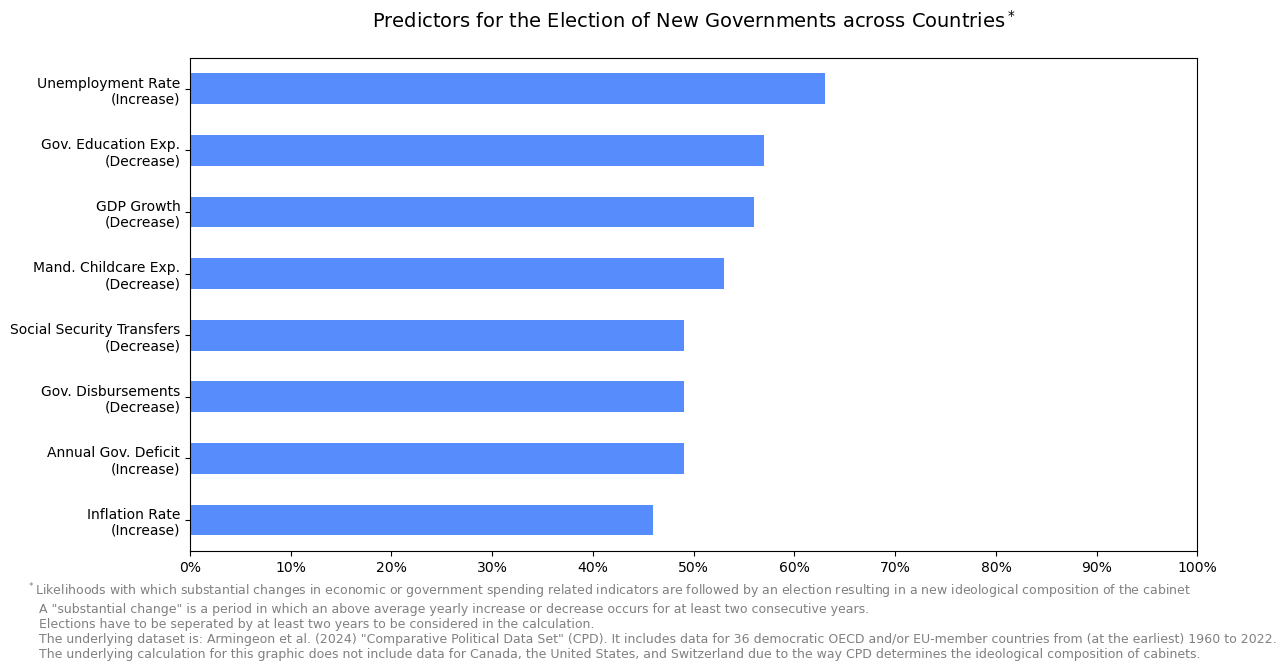

In [37]:
def plot_results_global(result_sr, label_dict, elect):
    # throw out None values and sort
    plot_sr = result_sr[result_sr.notnull()].sort_values().copy()

    # determine vertical figure size according to the number of predictors included
    plt.figure(figsize=(13, len(plot_sr) * 0.55 + 2))

    ax = plot_sr.plot(kind="barh")

    # use label dict to determine y_labels
    y_labels = []
    for predictor in plot_sr.index:
        # the index contains names like "incr_unemp", "decr_unemp", or "comb_unemp"; look only for "unemp"
        if predictor[5:] in label_dict:
            # add increase or decrease markers
            if predictor.startswith("incr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Increase)")
            elif predictor.startswith("decr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Decrease)")
            else:
                y_labels.append(f"{label_dict[predictor[5:]]}")
        # If additional variables are inserted into predictor_list and therefore included in all the calculations
        # above, they will still be assigned a label, but it will just be the original column name;
        # ideally plot_label_dict_final should also be updated instead
        else:
            y_labels.append(predictor)

    ax.set_yticklabels(y_labels)

    # show percentages in steps of 10
    ax.set_xticks(np.arange(0, 101, 10))
    # add "%" symbols
    ax.set_xticklabels([f"{tick}%" for tick in ax.get_xticks()])

    # don't show horizontal grid lines
    ax.grid(False, axis="y")

    # assign the correct titles and explanations (footnotes), depending on whether the predictors used are those for
    # new governments, continuing governments, or combined averages
    if elect == "new":
        title = "Predictors for the Election of New Governments across Countries$^*$\n"
        footnote_1 = ('$^*$Likelihoods with which substantial changes in economic or government spending related'
                    ' indicators are followed by an election resulting in a new ideological composition of the cabinet\n'
                      '   A "substantial change" is a period in which an above average yearly increase or decrease occurs'
                    ' for at least two consecutive years.\n')
    elif elect == "cntn":
        title = "Predictors for the Re-Election of Governments across Countries$^*$\n"
        footnote_1 = ('$^*$Likelihoods with which substantial changes in economic or government spending related indicators'
                      ' are followed by an election resulting in a continuation of the previous ideological composition of the cabinet\n'
                      '   A "substantial change" is a period in which an above average yearly increase or decrease occurs'
                      ' for at least two consecutive years.\n')
    elif elect == "comb":
        title = "Combined Predictors for Election Outcomes across Countries$^*$\n"
        footnote_1 = ('$^*$Combination of the two previous figures; shows the average predictive power for each indicator'
                      ' (increases and decreases) regarding election outcomes (new cabinet or continuation of cabinet)\n')
    else:
        raise KeyError(f"Unrecognized elect type: {elect}")

    # part of the footnote that is identical across figure variations
    footnote_2 = ('   Elections have to be seperated by at least two years to be considered in the calculation.\n'
                  '   The underlying dataset is: Armingeon et al. (2024) "Comparative Political Data Set" (CPD). It includes data for'
                  ' 36 democratic OECD and/or EU-member countries from (at the earliest) 1960 to 2022.\n'
                  '   The underlying calculation for this graphic does not include data for Canada, the United States, and Switzerland'
                  ' due to the way CPD determines the ideological composition of cabinets.')

    ax.set_title(title, fontsize=14)

    # add in footnote
    plt.figtext(0.0, 0.0, footnote_1 + footnote_2, ha="left", va="center", fontsize=9, color="gray")

    plt.show()


plot_results_global(result_sr=elect_new_predictors_global_sr, label_dict=plot_label_dict_final, elect="new")

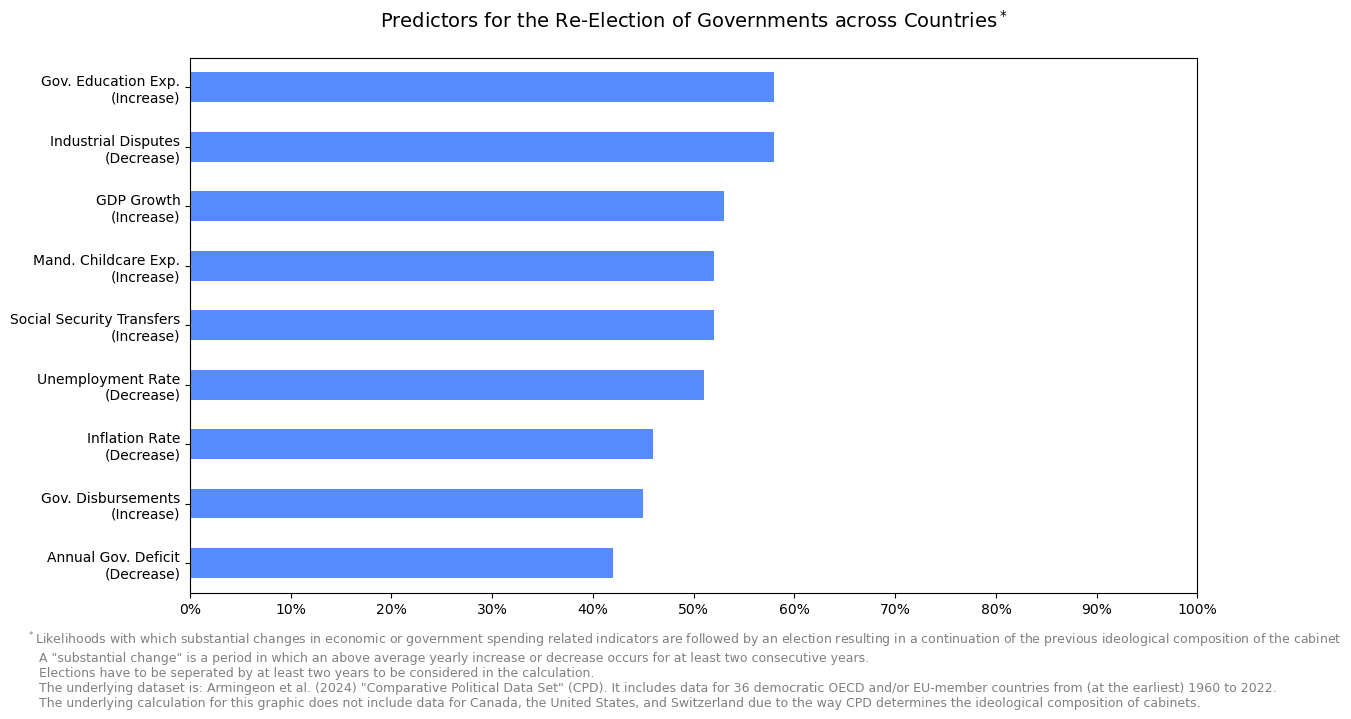

In [38]:
plot_results_global(result_sr=elect_cntn_predictors_global_sr, label_dict=plot_label_dict_final, elect="cntn")

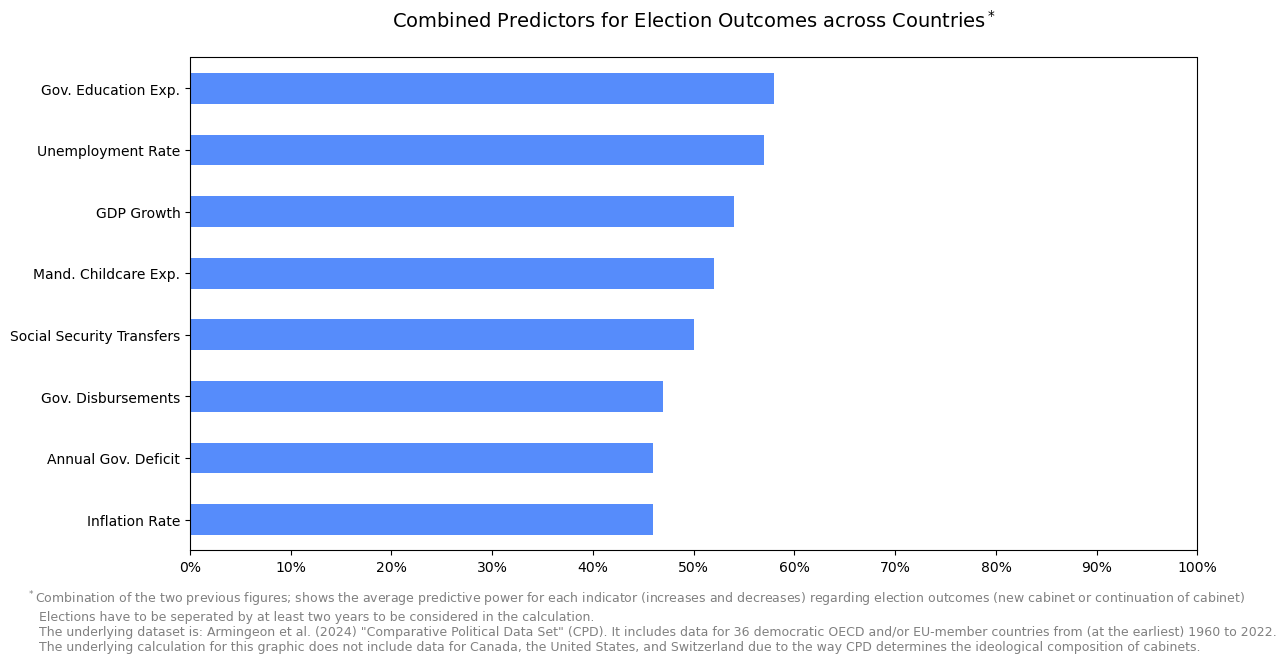

In [39]:
plot_results_global(result_sr=elect_comb_predictors_global_sr, label_dict=plot_label_dict_final, elect="comb")

Increasing unemployment rates are the strongest predictor of changes in the ideological composition of cabinets following an election. Decreasing unemployment rates are the third-strongest predictor of the ideological composition of governments being confirmed after an election. GDP growth and government spending on education also stand out in all three charts.

(To properly contextualize the high predictive power of decreases in industrial disputes for re-elections, a comparison with the inverse constellation would be helpful. Unfortunately, this comparison had to be omitted due to a low value count.)

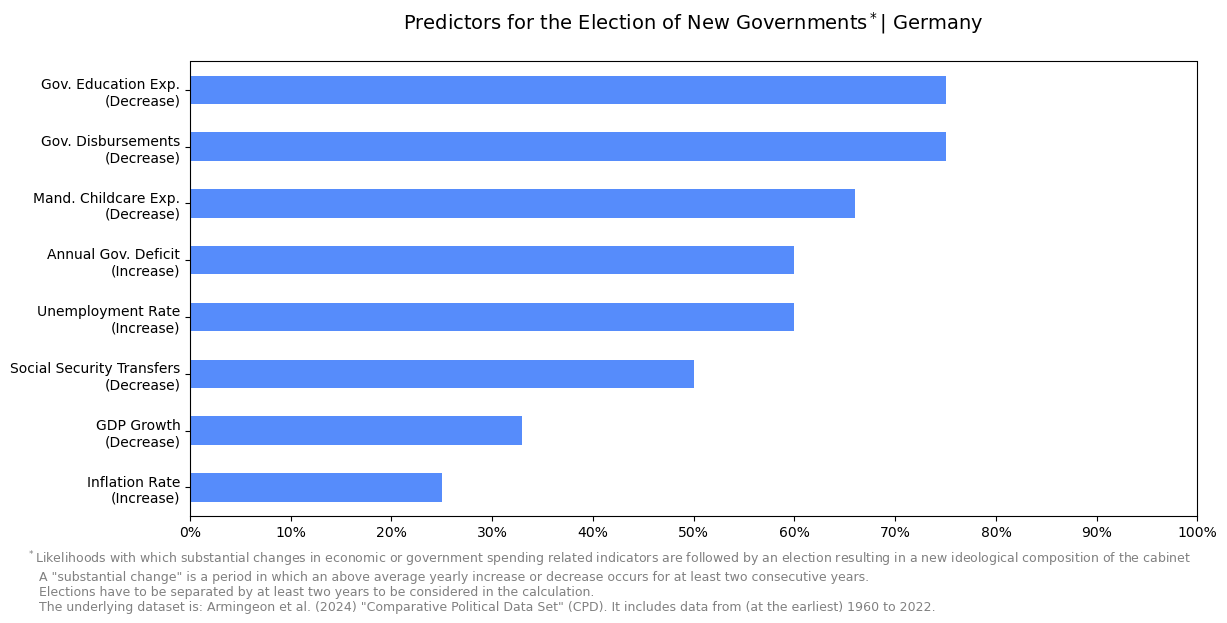

In [40]:
def plot_results_per_country(result_sr, label_dict, elect):
    # throw out percentages for which the corresponding value count is lower than 1.5
    # for the elect_new and elect_cntn series this will mean that the minimum is 2
    for idx, val in zip(result_sr.index, result_sr.values):
        if idx.endswith("_count") and val < 1.5:
            result_sr = result_sr.drop([idx, result_sr.index[result_sr.index.get_loc(idx) + 1]])

    result_sr = result_sr[result_sr.notnull()].sort_values()
    # throw out the counts/keep the percentages
    plot_sr = result_sr[[idx for idx in result_sr.index if idx.endswith("_perc")]]
    # get rid of the "_perc" endings
    plot_sr.index = [idx[:-5] for idx in plot_sr.index]

    plt.figure(figsize=(13, len(plot_sr) * 0.55 + 1.5))

    ax = plot_sr.plot(kind="barh")

    y_labels = []
    for predictor in plot_sr.index:
        if predictor[5:] in label_dict:
            if predictor.startswith("incr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Increase)")
            elif predictor.startswith("decr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Decrease)")
            else:
                y_labels.append(f"{label_dict[predictor[5:]]}")
        else:
            y_labels.append(predictor)

    ax.set_yticklabels(y_labels)

    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_xticklabels([f"{tick}%" for tick in ax.get_xticks()])

    ax.grid(False, axis="y")

    if elect == "new":
        title = f"Predictors for the Election of New Governments$^*$| {plot_sr.name}\n"
        footnote_1 = ('$^*$Likelihoods with which substantial changes in economic or government spending related'
                    ' indicators are followed by an election resulting in a new ideological composition of the cabinet\n')
    elif elect == "cntn":
        title = f"Predictors for the Re-Election of Governments$^*$| {plot_sr.name}\n"
        footnote_1 = ('$^*$Likelihoods with which substantial changes in economic or government spending related indicators'
                      ' are followed by an election resulting in a continuation of the previous ideological composition of the cabinet\n')
    elif elect == "comb":
        title = f"Combined Predictors for Election Outcomes$^*$| {plot_sr.name}\n"
        footnote_1 = ('$^*$Combination of the two previous figures; shows the average predictive power for each indicator'
                      ' (increases and decreases) regarding election outcomes (new cabinet or continuation of cabinet)\n')
    else:
        raise KeyError(f"Unrecognized elect type: {elect}")

    footnote_2 = ('   A "substantial change" is a period in which an above average yearly increase or decrease occurs'
                  ' for at least two consecutive years.\n'
                  '   Elections have to be separated by at least two years to be considered in the calculation.\n'
                  '   The underlying dataset is: Armingeon et al. (2024) "Comparative Political Data Set" (CPD).'
                  ' It includes data from (at the earliest) 1960 to 2022.')

    ax.set_title(title, fontsize=14)

    plt.figtext(0.0, 0.0, footnote_1 + footnote_2, ha="left", va="center", fontsize=9, color="gray")

    plt.show()


for cntry in ["Germany"]:
    plot_results_per_country(result_sr=elect_new_predictors_per_country.loc[cntry], label_dict=plot_label_dict_final, elect="new")

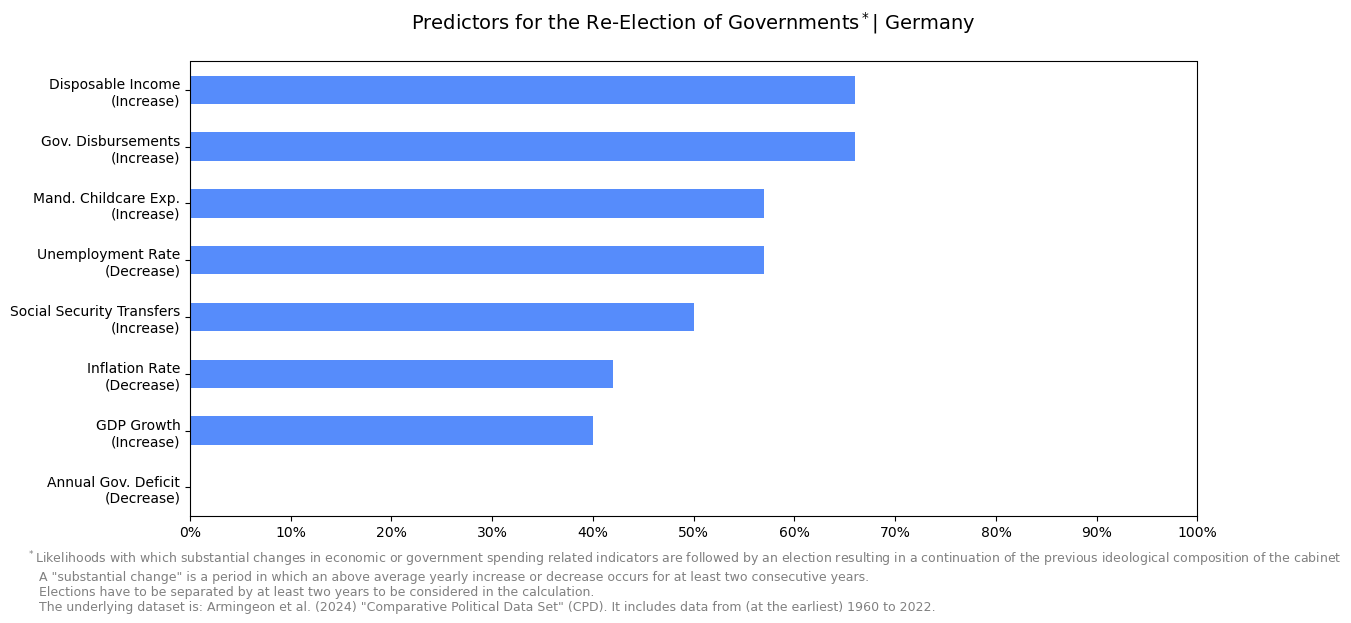

In [41]:
for cntry in ["Germany"]:
    plot_results_per_country(result_sr=elect_cntn_predictors_per_country.loc[cntry], label_dict=plot_label_dict_final, elect="cntn")

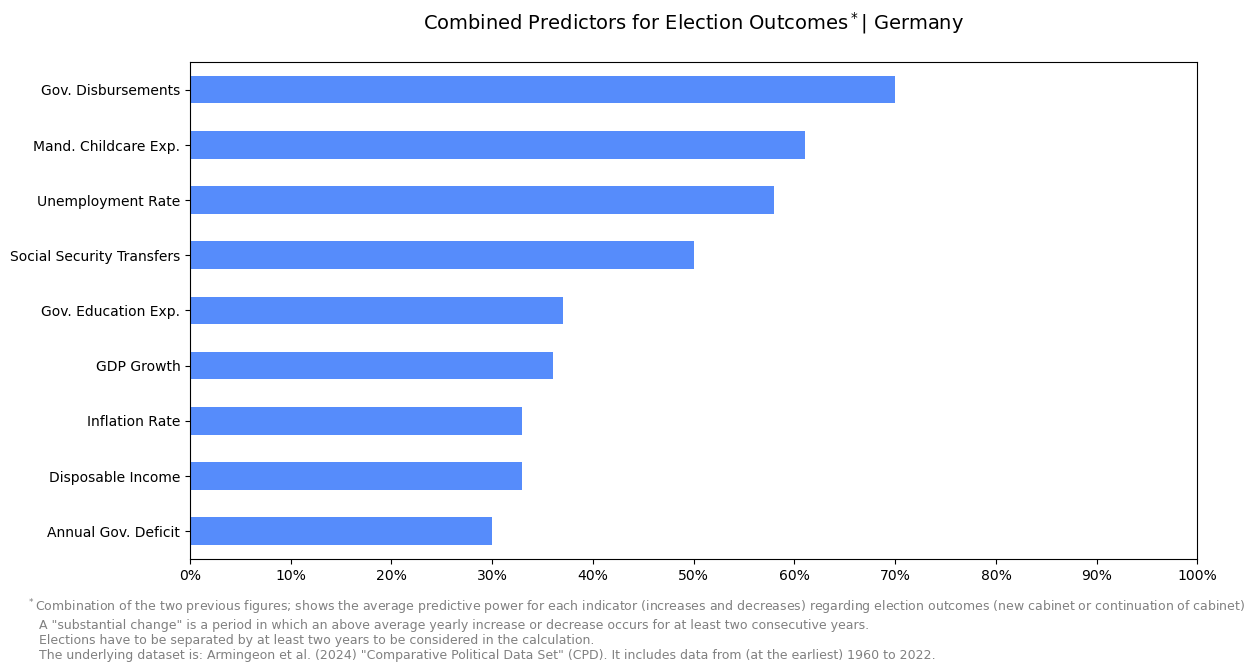

In [42]:
for cntry in ["Germany"]:
    plot_results_per_country(result_sr=elect_comb_predictors_per_country.loc[cntry], label_dict=plot_label_dict_final, elect="comb")

In the case of Germany, the disparity between the predictive power of government disbursements (provision of various financial resources) and government deficits is particularly interesting. The results suggest that German voters reward increases in government spending. While German governments over the past two decades have been somewhat notorious for their 'fiscal hawkishness,' the electoral rewards for reducing the annual deficit appear to be minimal.

(Caveat: The data considered spans from 1960 to 2022, and it is possible that attitudes toward government spending have significantly shifted in the last twenty years.)

When comparing the results for Germany with those across all countries, it is also noteworthy that the predictive power of changes in the GDP growth rate is considerably lower for Germany. Unemployment rates show high predictive power both across all countries and in the case of Germany.

In [43]:
# export results to csv
new_glob, cntn_glob, comb_glob = (
    elect_new_predictors_global_sr.copy().dropna(), elect_cntn_predictors_global_sr.copy().dropna(), elect_comb_predictors_global_sr.copy().dropna()
)

for table in [new_glob, cntn_glob, comb_glob]:
    table.index = [idx + "_perc" for idx in table.index]

new_glob, cntn_glob, comb_glob = new_glob.reset_index(), cntn_glob.reset_index(), comb_glob.reset_index()
for table in [new_glob, cntn_glob, comb_glob]:
    table["country"] = "All Countries"

new_glob = new_glob.pivot(index="country", columns="index", values="percentages_new").reset_index()
cntn_glob = cntn_glob.pivot(index="country", columns="index", values="percentages_cntn").reset_index()
comb_glob = comb_glob.pivot(index="country", columns="index", values="percentages_comb").reset_index()

for table in [new_glob, cntn_glob, comb_glob]:
    for col in table.columns:
        table[col].rename(f"{col}_perc", inplace=True) if col != "country" else None

elect_new_pdt = pd.concat([elect_new_predictors_per_country.copy().reset_index().rename(columns={"index": "country"}), new_glob]).reset_index(drop=True)
elect_cntn_pdt = pd.concat([elect_cntn_predictors_per_country.copy().reset_index().rename(columns={"index": "country"}), cntn_glob]).reset_index(drop=True)
elect_comb_pdt = pd.concat([elect_comb_predictors_per_country.copy().reset_index().rename(columns={"index": "country"}), comb_glob]).reset_index(drop=True)

for name, table in {
    "elect_new_predictors": elect_new_pdt,
    "elect_cntn_predictors": elect_cntn_pdt,
    "elect_comb_predictors": elect_comb_pdt
}.items():
    table.to_csv(f"app/assets/prepared_csvs/{name}.csv", index=False)

In [44]:
elect_new_pdt

,country,incr_unemp_count,incr_unemp_perc,incr_inflation_count,incr_inflation_perc,incr_deficit_count,incr_deficit_perc,incr_nld_count,incr_nld_perc,decr_realgdpgr_count,...,decr_sstran_count,decr_sstran_perc,decr_outlays_count,decr_outlays_perc,decr_educexp_gov_ipol_count,decr_educexp_gov_ipol_perc,decr_childcare_pmp_count,decr_childcare_pmp_perc,decr_postfisc_gini_count,decr_postfisc_gini_perc
0,Australia,3.0,33.0,5.0,60.0,5.0,40.0,2.0,0.0,5.0,...,1.0,0.0,4.0,25.0,6.0,50.0,2.0,0.0,0.0,0.0
1,Austria,4.0,50.0,3.0,0.0,4.0,25.0,3.0,33.0,2.0,...,0.0,0.0,5.0,60.0,4.0,25.0,1.0,100.0,6.0,66.0
2,Belgium,7.0,57.0,6.0,33.0,5.0,20.0,0.0,0.0,4.0,...,4.0,0.0,5.0,20.0,2.0,50.0,5.0,20.0,1.0,0.0
3,Bulgaria,1.0,100.0,2.0,50.0,2.0,50.0,0.0,0.0,1.0,...,4.0,50.0,3.0,66.0,3.0,66.0,0.0,0.0,0.0,0.0
4,Croatia,1.0,100.0,1.0,0.0,3.0,33.0,0.0,0.0,3.0,...,4.0,50.0,3.0,33.0,2.0,50.0,0.0,0.0,0.0,0.0
5,Cyprus,1.0,100.0,2.0,50.0,1.0,0.0,1.0,100.0,2.0,...,0.0,0.0,1.0,0.0,4.0,50.0,0.0,0.0,0.0,0.0
6,Czech Republic,2.0,100.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,66.0,1.0,0.0,2.0,100.0,0.0,0.0,0.0,0.0
7,Denmark,3.0,100.0,4.0,75.0,6.0,50.0,2.0,0.0,5.0,...,7.0,42.0,9.0,55.0,3.0,66.0,5.0,40.0,0.0,0.0
8,Estonia,1.0,0.0,0.0,0.0,3.0,66.0,0.0,0.0,1.0,...,2.0,50.0,3.0,66.0,1.0,100.0,2.0,50.0,0.0,0.0
9,Finland,3.0,33.0,3.0,33.0,4.0,25.0,3.0,33.0,5.0,...,4.0,25.0,4.0,50.0,9.0,44.0,6.0,50.0,0.0,0.0


## Brief discussion of some possible improvements

Let's consider some possible improvements to the accuracy of our analysis:

Since we only utilized data from the CPD main dataset, our definition of a "new" government relied on the "gov_new" column, which measures significant changes in the ideological composition of a government. This includes changes resulting from elections as well as those occurring for other reasons during an electoral term. As mentioned earlier, it does not capture changes regarding the dominant political party in Canada, the United States, or Switzerland.

An alternative definition of a "new" government, using data external to the CPD main dataset, could involve considering when there is a change in the political party of the head of government (chancellor, prime minister, president, etc., depending on the political system) following an election.

Another factor that may impact the accuracy of our analysis is the way we count electoral terms (see the discussion of the "create_elect_terms_dict" function above). An improvement could be achieved by storing the months between any two elections (for the same country) as electoral terms and adjusting other functions to work with monthly data. The first step would be to resample the dataframe to a monthly frequency, while interpolating all relevant columns, as shown below.

In [45]:
df_trends_yearly = pd.concat([df_cpd[["country", "elect_new_year", "elect", "elect_filtered", "elect_cntn_year", "year"]].copy(), df_cpd[df_cpd.columns.intersection(predictor_list)].copy()], axis=1)
# add a date column, created using the year column
df_trends_yearly["date"] = pd.to_datetime(df_trends_yearly["year"], format="%Y")
df_trends_yearly

,country,elect_new_year,elect,elect_filtered,elect_cntn_year,year,outlays,realgdpgr,inflation,deficit,unemp,nld,sstran,educexp_gov_ipol,childcare_pmp,postfisc_gini,date
0,Australia,None,NaT,NaT,None,1960,NaN,NaN,3.728814,0.458214,1.1,1145.0,5.500000,NaN,NaN,NaN,1960-01-01
1,Australia,None,1961-12-09,1961-12-09,1961.0,1961,NaN,0.036558,2.287582,-0.357625,2.1,815.0,6.100000,NaN,NaN,NaN,1961-01-01
2,Australia,None,NaT,NaT,None,1962,23.172518,5.464884,-0.319489,-0.793822,2.0,1183.0,6.000000,NaN,NaN,NaN,1962-01-01
3,Australia,None,1963-11-30,1963-11-30,1963.0,1963,23.012875,6.142928,0.641026,-0.506212,1.6,1250.0,5.900000,NaN,NaN,NaN,1963-01-01
4,Australia,None,NaT,NaT,None,1964,22.879796,6.201358,2.866242,-0.080390,1.3,1334.0,5.700000,NaN,NaN,NaN,1964-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1861,USA,None,2018-11-06,2018-11-06,2018.0,2018,37.931370,2.918856,2.442583,-6.294576,3.9,20.0,14.363617,4.91233,0.330,38.0,2018-01-01
1862,USA,None,NaT,NaT,None,2019,38.274317,2.288869,1.812210,-6.691546,3.7,25.0,14.562796,4.98871,0.339,38.1,2019-01-01
1863,USA,None,2020-11-03,2020-11-03,2020.0,2020,47.409843,-3.404589,1.233584,-15.785561,8.1,NaN,20.041934,6.05000,0.367,36.4,2020-01-01
1864,USA,None,NaT,NaT,None,2021,43.777934,5.559456,4.697859,-15.915125,5.3,16.0,19.633730,NaN,NaN,36.6,2021-01-01


In [46]:
def create_df_monthly(df):
    country_dict = {}

    # iterate over countries, storing the values for each country in a separate df
    for country in df["country"].unique():
        df_country_yearly = df[df["country"] == country]
        # set date as index to enable resampling
        df_country_yearly.set_index("date", inplace=True)

        # resample country dfs to monthly frequencies
        df_country_monthly = df_country_yearly.resample("MS").asfreq()

        for column in df_country_monthly.columns:
            # preserve the columns that won't be interpolated and fill in the yearly values for each month of the same year
            if column not in predictor_list:
                df_country_monthly[column] = df_country_monthly.groupby(df_country_monthly.index.year)[column].ffill()

        for predictor in predictor_list:
            # interpolate predictor columns
            df_country_monthly[predictor] = df_country_monthly[predictor].interpolate(method="linear")

        # store country dfs in dict
        country_dict[f"df_{country}"] = df_country_monthly

    # create monthly df from dict, recombining the country dfs
    df_monthly = pd.concat(country_dict.values(), axis=0)
    df_monthly.reset_index(inplace=True)
    return df_monthly


df_trends_monthly = create_df_monthly(df_trends_yearly)
df_trends_monthly[["date", "country", "unemp"]]

,date,country,unemp
0,1960-01-01,Australia,1.100000
1,1960-02-01,Australia,1.183333
2,1960-03-01,Australia,1.266667
3,1960-04-01,Australia,1.350000
4,1960-05-01,Australia,1.433333
...,...,...,...
21991,2021-09-01,USA,4.166667
21992,2021-10-01,USA,4.025000
21993,2021-11-01,USA,3.883333
21994,2021-12-01,USA,3.741667


### Addendum: Plots for Germany with German translations

In [47]:
plot_label_dict_ger = {
    "unemp": "Arbeitslosenquote",
    "inflation": "Inflationsrate",
    "deficit": "Staatshaushaltsdefizit",
    "nld": "Arbeitskämpfe",
    "realgdpgr": "BIP-Wachstum",
    "sstran": "Sozialhilfeleistungen",
    "outlays": "Staatliche Auszahlungen",
    "educexp_gov_ipol": "Bildungsausgaben",
    "childcare_pmp": "Kinderbetreuungsausgaben",
    "postfisc_gini": "Verfügbares Einkommen"
}

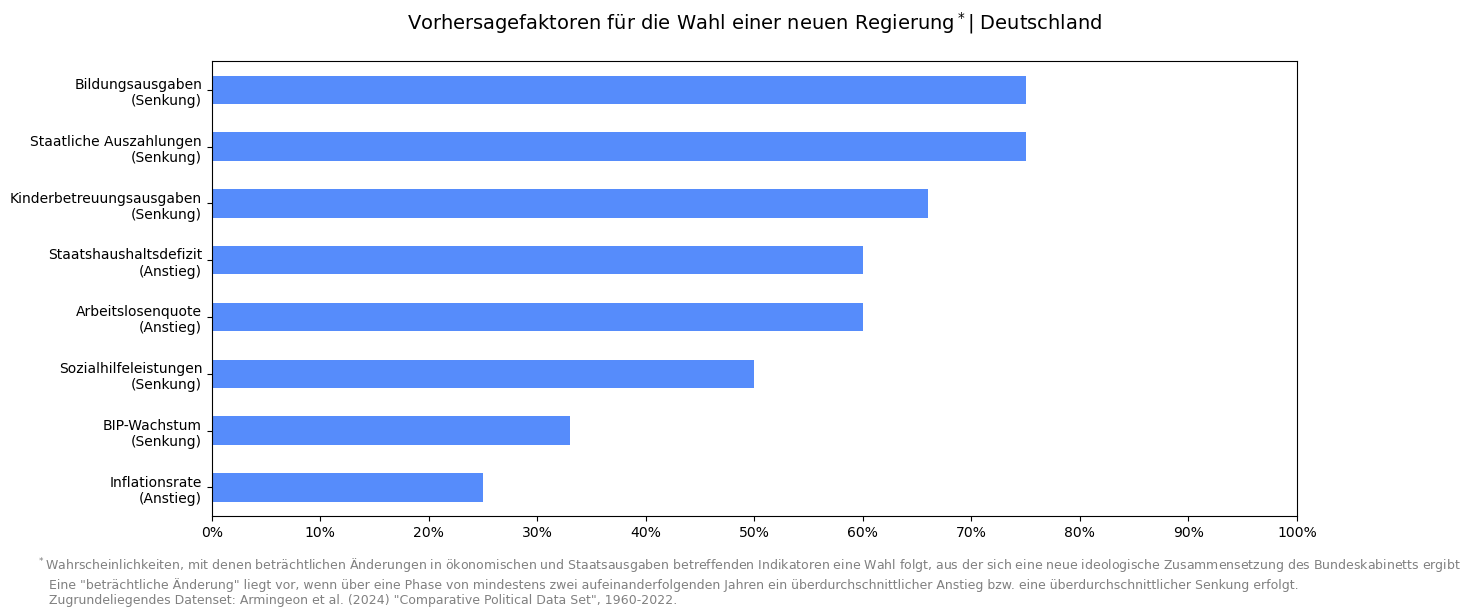

In [48]:
def plot_results_per_country(result_sr, label_dict, elect):
    for idx, val in zip(result_sr.index, result_sr.values):
        if idx.endswith("_count") and val < 1.5:
            result_sr = result_sr.drop([idx, result_sr.index[result_sr.index.get_loc(idx) + 1]])

    result_sr = result_sr[result_sr.notnull()].sort_values()
    plot_sr = result_sr[[idx for idx in result_sr.index if idx.endswith("_perc")]]
    plot_sr.index = [idx[:-5] for idx in plot_sr.index]

    plt.figure(figsize=(14, len(plot_sr) * 0.55 + 1.5))

    ax = plot_sr.plot(kind="barh")

    y_labels = []
    for predictor in plot_sr.index:
        if predictor[5:] in label_dict:
            if predictor.startswith("incr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Anstieg)")
            elif predictor.startswith("decr_"):
                y_labels.append(f"{label_dict[predictor[5:]]}\n(Senkung)")
            else:
                y_labels.append(f"{label_dict[predictor[5:]]}")
        else:
            y_labels.append(predictor)

    ax.set_yticklabels(y_labels)

    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_xticklabels([f"{tick}%" for tick in ax.get_xticks()])

    ax.grid(False, axis="y")

    if elect == "new":
        title = f"Vorhersagefaktoren für die Wahl einer neuen Regierung$^*$| Deutschland\n"
        footnote_1 = ('$^*$Wahrscheinlichkeiten, mit denen beträchtlichen Änderungen in ökonomischen und Staatsausgaben betreffenden'
                      ' Indikatoren eine Wahl folgt, aus der sich eine neue ideologische Zusammensetzung des Bundeskabinetts ergibt\n')
    elif elect == "cntn":
        title = f"Vorhersagefaktoren für die Wiederwahl einer Regierung$^*$| Deutschland\n"
        footnote_1 = ('$^*$Wahrscheinlichkeiten, mit denen beträchtlichen Änderungen in ökonomischen und Staatsausgaben betreffenden'
                      ' Indikatoren eine Wahl folgt, welche die vorherige ideologische Zusammensetzung des Bundeskabinetts bestätigt.\n')
    elif elect == "comb":
        title = f"Kombinierte Vorhersagefaktoren für Wahlausgänge$^*$| Deutschland\n"
        footnote_1 = ('$^*$Kombination der beiden vorangehenden Grafiken; gezeigt wird die durchschnittliche Vorhersagekraft für jeden Indikator'
                      ' (Anstiege und Senkungen) mit Hinblick auf Wahlausgänge (neue oder fortgesetzte\n   ideologische Zusammensetzung des Bundeskabinetts)\n')
    else:
        raise KeyError(f"Unrecognized elect type: {elect}")

    footnote_2 = ('   Eine "beträchtliche Änderung" liegt vor, wenn über eine Phase von mindestens zwei aufeinanderfolgenden Jahren'
                  ' ein überdurchschnittlicher Anstieg bzw. eine überdurchschnittlicher Senkung erfolgt.\n'
                  '   Zugrundeliegendes Datenset: Armingeon et al. (2024) "Comparative Political Data Set", 1960-2022.')

    ax.set_title(title, fontsize=14)

    plt.figtext(0.0, 0.0, footnote_1 + footnote_2, ha="left", va="center", fontsize=9, color="gray")

    plt.show()


plot_results_per_country(result_sr=elect_new_predictors_per_country.loc["Germany"], label_dict=plot_label_dict_ger, elect="new")

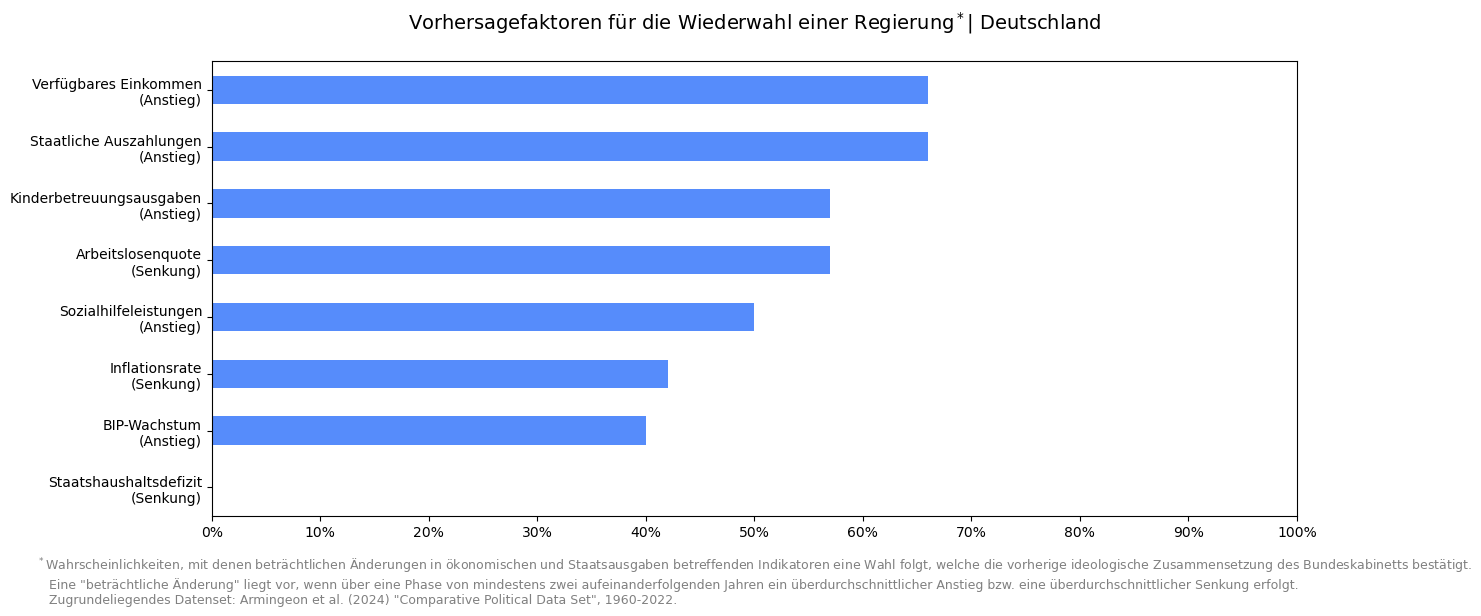

In [49]:
plot_results_per_country(result_sr=elect_cntn_predictors_per_country.loc["Germany"], label_dict=plot_label_dict_ger, elect="cntn")

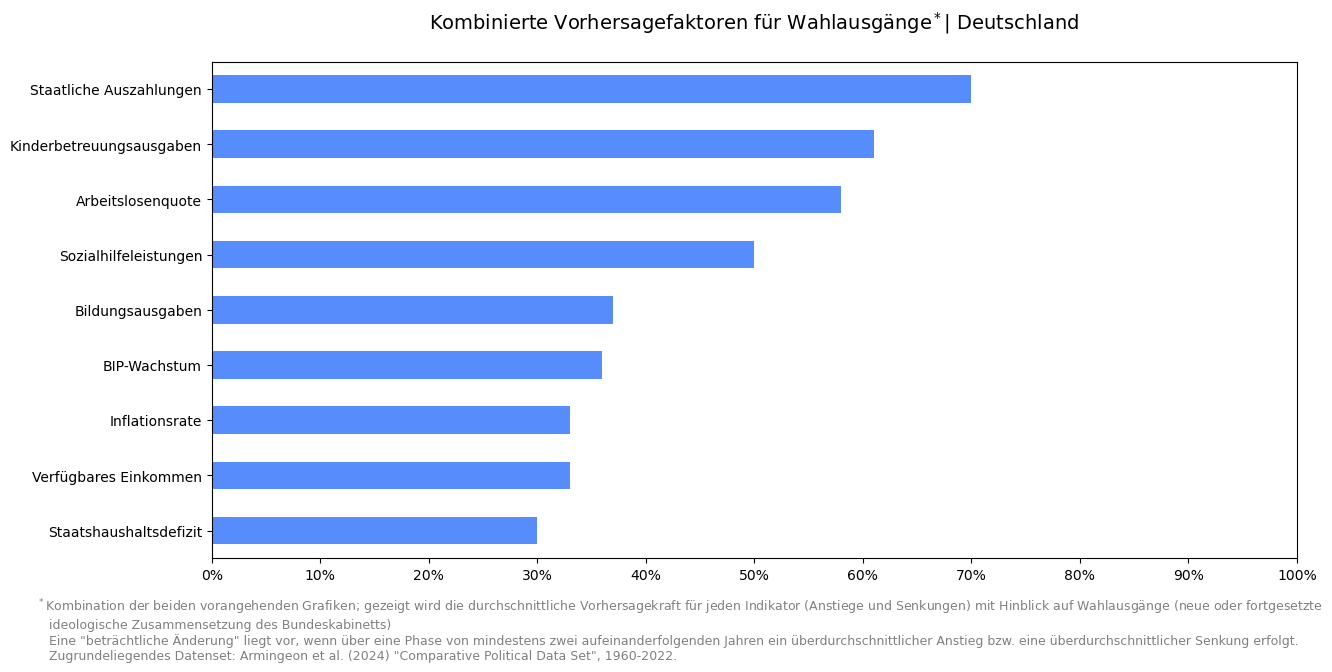

In [50]:
plot_results_per_country(result_sr=elect_comb_predictors_per_country.loc["Germany"], label_dict=plot_label_dict_ger, elect="comb")